# BOE OCT Fold 1 Pilot: Fast End to End Colab Notebook

This notebook consolidates the OCT work completed so far and implements Professor Lee's requested full one fold pilot.

**Primary research question:** Do adjacent B scan context and local thickness supervision improve RPEDC segmentation in a way that also reduces RPEDC thickness error and excess RPEDC volume error?

The three frozen pilot arms are:

1. **2D baseline:** current B scan repeated in three channels.
2. **2.5D context:** previous, current, and next B scans.
3. **2.5D + thickness:** the same 2.5D input plus local A scan thickness supervision with weight 0.1.

The measurement endpoint is **excess RPEDC volume**, not anatomical drusen volume. The primary normal reference uses model training controls only, age matched radial bin means, and `normal mean + 3 × normal SD`. `k=2` and `k=4` are sensitivity analyses.

This notebook also evaluates annotation dependence by comparing the current label assisted ROI center with a geometric scan center. The scan center is a pilot sensitivity analysis, not a validated foveal localization method.

**Important scientific guardrail:** this notebook never calls the outer test evaluator. Pilot measurement analysis is restricted to Fold 1 validation subjects. Calibration and outer test subjects remain untouched.

The notebook is designed to be safe to rerun. Completed full training arms are copied to Google Drive and restored on a later runtime. The supplied official trainer does not support mid epoch or mid run resume, so an interrupted individual arm must restart from the beginning.

This version keeps the BOE scientific comparison intact while reducing iteration time with mixed precision, faster CUDA convolution selection, pinned/nonblocking transfers, persistent workers with a bounded subject cache, a larger training batch, and a larger validation batch. The same speed configuration is used for all three arms.


## 1. Configuration

Review this cell before running the notebook. The defaults match the work already completed in this project.

In [1]:
from pathlib import Path

# ---------- Google Drive dataset and results ----------
RAW_DATASET = Path("/content/drive/MyDrive/Drusen_Dataset")
AMD_DIR = RAW_DATASET / "AMD"
CONTROL_DIR = RAW_DATASET / "Control"

DRIVE_ROOT = Path("/content/drive/MyDrive/BOE_OCT")
DRIVE_RESULTS = DRIVE_ROOT / "results"

# ---------- Local Colab paths ----------
REPO_DIR = Path("/content/retina-drusen-volume")
WORK_ROOT = Path("/content/BOE_OCT")
BOE_DATA = WORK_ROOT / "data" / "boe_duke"

# ---------- Repository provenance ----------
REPO_URL = "https://github.com/vsi-lab/retina-drusen-volume.git"
BASE_COMMIT = "a9d697b78ff0ca98d2526130cad5c27654827af4"
BRANCH_NAME = "boe-public-oct-volume"
GIT_NAME = "Puneeth"
GIT_EMAIL = "puneethsamarla@arizona.edu"

# ---------- Verified Duke spacing in micrometers ----------
AXIAL_UM = 3.23
LATERAL_UM = 6.54
BSCAN_UM = 67.0
SPACING_SOURCE = (
    "Asgari et al., Multiclass segmentation as multitask learning for drusen "
    "segmentation in retinal OCT, MICCAI 2019; Duke/Farsiu RPEDC dataset, "
    "Bioptigen SD-OCT."
)

# ---------- Frozen Fold 1 pilot settings ----------
FOLD = 1
SEED = 42
FULL_EPOCHS = 60
PATIENCE = 10
BATCH_SIZE = 8
WORKERS = 4
LEARNING_RATE = 3e-4

# ---------- Execution-only speed settings ----------
VAL_BATCH_SIZE = 16
AMP_MODE = "auto"          # BF16 on L4/A100; FP16 fallback on GPUs without BF16
FAST_CUDNN = True          # cuDNN benchmark + TF32; disables strict bitwise determinism
CHANNELS_LAST = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2
CACHE_SUBJECTS = 8         # bounded per-worker cache to avoid RAM growth
RUN_SPEED_TEST = True
BOOTSTRAP_N = 5000

# ---------- Run controls ----------
RUN_UNIT_TESTS = True
RUN_QC = True
QC_APPROVED = True  # Already reviewed for the current 384-subject Duke cohort.
RUN_ONE_EPOCH_SMOKE = False  # Set True on a new machine if you want the 3-arm 1-epoch check.
RUN_FULL_PILOT = True
RUN_VALIDATION_ANALYSIS = True
RUN_EXAMPLES = True
FORCE_REPREPARE = False

print("Configuration loaded.")
print("Raw dataset:", RAW_DATASET)
print("Prepared data:", BOE_DATA)
print("Drive results:", DRIVE_RESULTS)
print("Fast training: batch", BATCH_SIZE, "| val batch", VAL_BATCH_SIZE, "| AMP", AMP_MODE)

Configuration loaded.
Raw dataset: /content/drive/MyDrive/Drusen_Dataset
Prepared data: /content/BOE_OCT/data/boe_duke
Drive results: /content/drive/MyDrive/BOE_OCT/results
Fast training: batch 8 | val batch 16 | AMP auto


## 2. Mount Google Drive and check the Colab GPU

The raw Duke files are read directly from the shared Drive shortcut. They are not copied into your personal Drive. Prepared arrays stay under `/content` and are recreated after a runtime reset if needed.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

import shutil
import subprocess
import torch

DRIVE_RESULTS.mkdir(parents=True, exist_ok=True)
WORK_ROOT.mkdir(parents=True, exist_ok=True)

local = shutil.disk_usage("/content")
print(f"Local Colab free space: {local.free / 1024**3:.1f} GB")

nvidia_smi = shutil.which("nvidia-smi")
if nvidia_smi is None or not torch.cuda.is_available():
    raise RuntimeError(
        "No NVIDIA GPU runtime is attached. In Colab choose "
        "Runtime > Change runtime type > GPU, reconnect, and rerun from the top."
    )

subprocess.run([nvidia_smi], check=True)

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 supported:", torch.cuda.is_bf16_supported())

if not RAW_DATASET.exists():
    raise FileNotFoundError(
        f"Dataset shortcut not found at {RAW_DATASET}. Add the shared Drusen_Dataset "
        "folder as a shortcut under My Drive and rerun this cell."
    )


Mounted at /content/drive
Local Colab free space: 193.2 GB
PyTorch: 2.11.0+cu130
CUDA runtime: 13.0
GPU: NVIDIA L4
BF16 supported: True


## 3. Dependency check

The BOE patch requires NumPy, SciPy, pandas, scikit learn, PyTorch, and matplotlib. Colab normally already contains compatible builds. This cell only installs a package when the installed version does not satisfy the BOE range.

PyTorch is deliberately not replaced automatically because Colab's CUDA matched PyTorch build should be preserved. If CUDA is unavailable, switch the Colab runtime to a GPU before continuing.

In [3]:
import sys
import subprocess
import importlib.metadata as metadata

try:
    from packaging.requirements import Requirement
    from packaging.version import Version
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "packaging"], check=True)
    from packaging.requirements import Requirement
    from packaging.version import Version

required_specs = [
    "numpy>=1.26,<3",
    "scipy>=1.11,<2",
    "pandas>=2.1,<4",
    "scikit-learn>=1.3,<2",
    "matplotlib>=3.8,<4",
]

to_install = []
for spec in required_specs:
    req = Requirement(spec)
    try:
        installed = Version(metadata.version(req.name))
        ok = installed in req.specifier
        print(f"{req.name:15s} {installed}  {'OK' if ok else 'UPDATE NEEDED'}")
        if not ok:
            to_install.append(spec)
    except metadata.PackageNotFoundError:
        print(f"{req.name:15s} MISSING")
        to_install.append(spec)

if to_install:
    print("Installing bounded BOE dependencies:", to_install)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "--upgrade-strategy", "only-if-needed", *to_install],
        check=True,
    )
    print("Dependencies changed. If Colab reports binary/import conflicts, restart the runtime once and rerun from the top.")

import torch

torch_version = Version(torch.__version__.split("+")[0])
if not (Version("2.2") <= torch_version < Version("3")):
    raise RuntimeError(f"PyTorch {torch.__version__} is outside the BOE requirement >=2.2,<3")
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. In Colab choose Runtime > Change runtime type > GPU, then rerun.")

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))

numpy           2.1.3  OK
scipy           1.16.3  OK
pandas          2.2.3  OK
scikit-learn    1.6.1  OK
matplotlib      3.10.0  OK
PyTorch: 2.11.0+cu130
CUDA runtime: 13.0
GPU: NVIDIA L4


## 4. Clone the base repository and apply Professor Lee's BOE patch

The patch is embedded in this notebook so you do not need to upload it separately. The cell is idempotent: if the BOE source files already exist, the patch step is skipped.

In [4]:
import base64
import gzip
import os
import shlex
import subprocess
from pathlib import Path

PATCH_GZ_B64 = """..."""
PATCH_PATH = Path("/content/boe-public-oct-volume.patch")
PATCH_PATH.write_bytes(gzip.decompress(base64.b64decode(PATCH_GZ_B64)))


def run_cmd(cmd, cwd=None, check=True):
    print("$", shlex.join([str(x) for x in cmd]))
    return subprocess.run([str(x) for x in cmd], cwd=cwd, check=check, text=True)


if not (REPO_DIR / ".git").exists():
    run_cmd(["git", "clone", REPO_URL, REPO_DIR])

# Make sure the requested base commit is available.
run_cmd(["git", "fetch", "origin"], cwd=REPO_DIR)

boe_marker = REPO_DIR / "src" / "boe" / "train.py"
if not boe_marker.exists():
    tracked_changes = subprocess.check_output(
        ["git", "status", "--porcelain", "--untracked-files=no"], cwd=REPO_DIR, text=True
    ).strip()
    if tracked_changes:
        raise RuntimeError(
            "Tracked repository files have local changes. Save or revert them before applying the BOE patch."
        )

    run_cmd(["git", "switch", "-C", BRANCH_NAME, BASE_COMMIT], cwd=REPO_DIR)
    run_cmd(["git", "config", "user.name", GIT_NAME], cwd=REPO_DIR)
    run_cmd(["git", "config", "user.email", GIT_EMAIL], cwd=REPO_DIR)
    run_cmd(["git", "am", "--abort"], cwd=REPO_DIR, check=False)
    run_cmd(["git", "am", PATCH_PATH], cwd=REPO_DIR)
else:
    print("BOE source already present. Patch application skipped.")

# Verify that the BOE patch is based on the requested repository base.
ancestor = subprocess.run(
    ["git", "merge-base", "--is-ancestor", BASE_COMMIT, "HEAD"], cwd=REPO_DIR
).returncode
if ancestor != 0:
    raise RuntimeError("Current BOE branch is not descended from the specified base commit.")

head = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()
print("Repository HEAD:", head)
print("BOE train.py exists:", boe_marker.exists())

$ git clone https://github.com/vsi-lab/retina-drusen-volume.git /content/retina-drusen-volume
$ git fetch origin
$ git switch -C boe-public-oct-volume a9d697b78ff0ca98d2526130cad5c27654827af4
$ git config user.name Puneeth
$ git config user.email puneethsamarla@arizona.edu
$ git am --abort
$ git am /content/boe-public-oct-volume.patch
Repository HEAD: f4661738bb6869a82fed3c255d7ffa4e98e681fe
BOE train.py exists: True


## 4B. Install the speed optimized BOE trainer

This replaces only `src/boe/train.py`. The U Net architecture, fractional targets, masked BCE + Dice objective, local A scan thickness loss, Fold 1 split, and validation subject macro Dice selection remain unchanged. Speed changes are execution level and are recorded in each run configuration.


In [5]:
import base64
import gzip
from pathlib import Path
import py_compile

OPTIMIZED_TRAIN_GZ_B64 = """H4sIAHYKxGoC/+08/Y/bNrK/+6/gc/Ee5MRW1rvJothXFWiTbHF4vSS4Jnc/GAuBlui1bvV1orRfRf/3NzMkJZKSd52ivZ/O2NYWORwOh8P54ijz+fySy5YVvE32ImWn79grdhq+ecd+/PietQ3Pyqy8ZndZu2ftXrCqya6zkudMJpko22yXJaza/lMkbXYrwtns8z6T7EaIWrrgRZWKfMl2DQfIClta3lyLVi5hankDM//49v2rd1kiWF5JaM2rhOezH1Yy4SWgypKbUkipO3dVnrKaN22GyJaMlym75XmWcnxmsiOKVgVPmooh0hksLrmpq6xsmRS5ICJC9kstYOaqbrMie6SxkvFGMHEvkg4fV1WZPxB6cV/nWZK1+cOsEUnVpDAwK1lSlbvsOvynBHSz+Xw+y4q6alrAcg30SWGeEcD8bgBfVcx2TVXA+FxTI5nu/gi4G5EC2a2CqXm7z7Ot6f8EjzODq+yKGgiUrKxNUw3ooQH+6tS0tVWT7BU2+mlwlaXVGJalad91pdknwHNpAwFfchkCp7kBfge/pWiX9OPnigP5MzUiBEaJHme/97Ha+yVLs2sh4fuuyVoRE49ms1Ts2Ba2/ybgS7ZdXMwYfBrRdk0J9Ia/iH91KHk8D6gHP9D8tipvT1MasmRnS+BCmoLkRuvF0gb7qam6+kPVFMFrRO70/U38/CVwmzTW7R+EdQHLS3IOcvzlg2gD6P1rlXa50IsE+fmrPocyafAX+7ICwP9lZyBrddeyZM/LUuQSTkDDtlWLG8mvBYphK+5bGaIIIipkYhzD4W3jOACJ3wGTs7TdR+tzPRl+ZFeLJliEPeRi6IIxoSgTFrGezJ8z2QabHgQ/aqPONHZr5UMn9WgA9oKdHgbC3gHw9ZOArwfAby3AK28FqThuBQbX+mgCzo9d0gRzfCr3gqeKTC1wmmdr+AOZMRsKm37Hm1Tv5729kTcZaNyIba76JpSQDPQofxANaioBqkKAUInAbK01Hj/ZjmVuC37uAetlWPD7uK6qHEi7X8J6Zz4ITRPcux1EVcjrWpQp9jm00YglwSB5j1kdmB1bwnG/FaA9YamIYnOxWl8tPHIVYaDQRVNXOa5rTPty1CSzRxEh0lDueS02q9OLqzEUWqtovs3yrBS8mY8BwNZclzFotxLIjC55LoULdIhDSocmHKTwXi3+CvfY4o3WdL1cEOOUUuyyPI3JkgYc0IDOTABWGPlS/IFttDtZFLF5V4p2fuFPQTpIDVXTa0UtxXUBGpbsoZpOxvWDshtgDWRR2yoZHsMvgP9T3kn8b9gGEDEY3MQlL4CbjZAAdfba4qYBuBPZ9b6V0YeqtNiYAYO1uovOhmbSn0JGa1+lfnz7WVuiQH8PavUDR/9kBTRUORl2hGapAlPeDQd92pVo1kEnru6q5gbOjfYkWMJBK5NyHWtX5ygvLd1KQ6VFuVLS0fw0tZjAO+K2L0Q0Y2yQRN/q1V64isP0g3yZnyEsUrRAXCrug7Sp6uhz0wlP4WhSYJj+5XZrmqBb//JGO7QBFKiHAE5i4HYsluzEm5eocvXUgBHaLd8n8PQF6LKmukNV4aw8BEFvoEMGnn6gTS3rMAeHJECfKQCoEH2pBbi485xvQbDCsn6cL1Cq1fNY/3WSb3MkDVBlcod7LgIFvJn3fun8ahHy8iFYewqwX3MIPEYtGMAyHhe0oEdcC2DdgfIqq/JRNFWgZlssbDHLRalt+GJ0hKEvGCaxh+GyzU5ogyGz1MIAegIaen7SDngGoRUFClbfHdYVKGnAMl4k9W+g7wpG4EAHRFNL7cMSYDcjfzPBchKWgUz0b6TiP22lg3i8rwoe9vXBU9tFwetYKXZbow9r+QMEpgNT15CuV/JBz/MrOG71Q+ByLa/uHFB6HkBn3iYEal1LNcVSDbfBdpNH83t2cvG1m3W3z0Dge8ki4AVgmsA/Pi6usCBuOCxSa7exlRskQsk6RAXY1Pusma3wshTOjhEZEvhNdvW7xMlloxnmnRmU8zF/jeIEqwpq3DswZQqxJvlhj0Aq/A0TwyaLg9BjBwQU6iNboQN4shi7H48TLktWwoiXOAK3Tq1zgSi88VczlxnqaPGm4Q/u2VIoNppMz0tK24caTtIOWNaendrnCfMHb96EJ8M0JtqjCB2mGwWCwfgQbR69CWmnRq1odPCU7smDWNjH2g5yyK2hdW4b2OMEJDJuK3daos7FrqhTnqKFenxGd67ZxHyBCvJD9RUs2HfsJHxzMWYwnkD83lwsGf6hqzulLxQtAK1+bJ6CHVasf42g/XP4qzNeKdH5hY74MZSPKdGgxMoTqLmiaApc04p+3ZU/ivg9NWisU/QiCE0IeweiF/Si5y7dn4XfZyBmXQET0QCSFtPoA+ujD7AIpZ8GmN+0H445G4qjeFHncMjUru5RS/ew7irwOIOOV2y90qHH+orcAEkmWKNyRr1kZ+sJO/XqFTs7Vd4gRpfq593Xzn76R81Ov6sOpe3X39QTIr4RD4g60NMuezFZmq23VDsM38AANEdKHGTLIYJ29eIl2OJ0Qjpo5FghjiHxc7KcbL4DRakQ9exZfs34vT9+PTF+8VSI6G+GnSswLN4M4jywCtxKWTXDajfSAfPxWnQpHa7PnzpNJqbqJzRH4soxU9LumKRcWxmtXgCVPjsq2RtjGleRnFfXmQmStKGYeerYrEYDGZ9bh43L2RDmfezTzTqn/PG9k51GsM99LpmyX7eZxHCwEQXPSqnSzheUu74VTZvBE6uSpKt5mYBA46CiEOlMG3CBqQ1Q+ZgkbhkmLR60mdOZa9AVXVGyrdhhJvSXosKc3c9rxMTrOs9EGhri6btuqi16hcSVUGbXRZWlRmEnEKDiOaMZQD8VQQDm/nTJzhZglHJgf4xugEkZbRPhaIXLcAvMaR7ipAH2x0A2RIcPMfq9sZow8EzusDWeLfe8+7Qjgx7NIY4Rk871C0W0Ei+PdPAYaGXaEcyI7DWcqIGcU0AQEG9eGEuoMfrIZoP+WovV+cz4JJZy1HieGx78jonMPuGmx8bfoW80wSdgvVAZ9zm9bLeDcLf09okIVPBmcvWkSLBizJUh8lloVNbmHGE32dKZe6A8YZEkrHG+tk5rrzoGyl+x9UnoqUWlUzCilXGe3YhggF/8HtmxGWqJ0FqJztCnWyfOglZEwypOwteAGI6ItY8n4Tm0oQBajb6+QQk0TZqWQvAyMFm6GKcm1Rqk4hZwLRkRA5HnkKFTPSFCsf+CUCLpUj5noEgNKAUY1W43ztrhzs36TJ8Nvt2tz+dOgF9W+uonxAnCTMYIE2uHSqR+zqThmRTsb3AWs0K8bxrbrvRe0o+X63Mg5l+dkICCbcH0t3jr9/bLux/YT5++sLSCqAanNn4ojgjnB4yfXpYic0t2aH0+vcBd7SzQGekM/Ibxrq0MjmM5ME3J4Zlou/W1o84+q2tObdjwImypg1sSBGXNjHhY6U6T54yHWLk3a4QyFDCP9vJJV0rL3VKXs0RbVupjRkyzF0cXRnSlBJZa0TYdjRDQ4C36YZK/HPsDJzimuw+8IsOso+/w+PcNzropbLIPRmQOxjjN4IROFJRn113VyWmnrxBFBWYPWFDwVjs8ztRjV202ziWqcShYGD8e4kpMW2stY8wmtfu9HIwBRIlZwDQKehj0F/BEocj4buSYOzVo1Yy0qqPS/RuOXIdzkwCW7zHV/X2E8exzfHMIGR7CpO4CD7RtunY/iJ8OFq6mJjJ2VYOqaOIq3FZV7mPViWOTxneuwfTw3pGdYCR3yN5kV+x/tIW1Ek/9rR+65LgKD24ECD2dSWmqvMtmkscBBzRbZeoWIeXSFtPhB3dgwGhtnxl0tRiTpfTKRvPj6qDoKLhwlLdxQ3Yvdh6pilq5B8HpgSVNi91LzbxDgqdtniLR0uxk1/6OQyes2vxDBboHxnG0Z3YdCXjwcu7nlLQxUOmEmbUgcgPcrQzQcb3fgGumvER3VeCV3mMaYKoPJfdeVZgQu9W6rdOo75CN20G5S6yLCfBWS5XIaImmWo1I5crxt15HIVquu6h8BTFYCpRAMfENB6DmDXGE6lzmi7ARMBnmQYPFzOX+MF7VdvRY+pxsIm+tnA04P4aOzTyp9mCUY4igT9+cz4cTBqzwsUHo9DQuBeHiWhwtEZ9ozSANiiSkQCEkk3UNHXzXiobtGiEewdqNhMS6HKtTxS8g1uLOFFus4FvP9tzogQ32PqgKJ4E6UkFYkbsaQQVUYF/x247XnR00aEwmLEw7rIHi5DbRddfC3iK8ePWHOJtDAGa9DsDxG3OJhBedbIfyLx12Gx0v7nmC8XgFXtBoWyhTa5HZVLlYIG1DAnRORW9WIIIGxn5M3McW5FI///Z1y0AfOmvAEtCMlB9fsgT/hzgZ0nZQ+/R8BGN2LcZ7NhCIoZWxcUOrcVujOXgUcVvFQ/DVBzIFvxGxchWDXpFIE/2T+YyxnkI9qxtznS6Q+263y3XPtSjR4lbaGa6zMlYemX6GURmEEmUbOzhA7+wEzrGDDcXBWkpu7sA3wKOBZtk9E0Bc5BDpEhr5NFukRg7JpNG7whAUOYTpEB9zwPGujPTPoW9YYOSv1RJDNd0gMWpZm3nPLcq59U/9QE2Ke7VnBo95SVjGzeORLrfVMLfNEcCh1i948UIhWfQ5Pgi89WbVWEOgayHDH5rrDi9IPuGTdSRSIZMmqykNEMdplcSxza1v2MeJqlOukUmVQANXKk1j0xjMVysUhPnSnLLUKoMYw1ZdeywoqkyAJR8+K9sjR0kh3FHAKN7lbfT6dHLIoF9WK33naJ3eZF/hnVy0oVISNj+t34AHbGV2NfKh0uTZSeyaocmZqIZoqWqJ6npyNgVyeD6YhsqNJhmxPn+Wxj7vslKpGItOwkcu2ZiuPj11iChRV8leTlJ1fnJoUA0eEUba04s5eXYxpItWqIv8ZSCm0SJeP8NXfdonRezQoLwx8Ipz/YgzsXrdH773bjG07Gumq3L67NmrBDvztSu1col7kdeRZzr/PvjnKp+BiEN2wjppTClWrNt9bupp/pbjXcVOwGK2guUYaTbwK+GAwXb/91hWXQGmBPUbFpxLaaWxFseerKKePFCY3YPzhAkF/Kbs3VInuaZOF8EfN+WOy3aVdGlp+zFc51klqHIw+aCs5k9z+j2lIVjSvfvwAfhTJvuCNzevPl+enapcTaZqo2TbgCX2uZwKcJAL2AzZgrZWSPq6+t/BRpOwWWHC5phlPYtxsIrD8fkj0GqrudKW9BiZPz2WCVhZszLO31Gov3U8D+061SFZZJxEBgv7DpeiRGwO4dmK67AXIo4teKZh3UIMKO6Bd07VnfJ5L7NcvKe+Kcf3C0BwDJvknjVdCTLUCOTSw5SrPowlgpSaZt+xtR12UJeqtf5v9nrUM0rff8dORkCDXziNXbtcU0M9H2lyvFeUZdAcH/X8pVQ5r167GeEYhweq7ATdDbWL+EuJVVmHT/Sq7GbBy47nsQ8wnUnntzzLUQPYQmCBWMhinudTCKkJtVVM2orUytGToGIWZSpDGhu6CidilEZ/ekiv1AAcvbcnoHE5bdHlIaykuovbHSjBZwfBFM+BY62uvnyP1QwxiFRCt9LBfA8iqzMcbgHZURx4njqbAYpfqoCj4YWga2iTVHJPIqWY3CaEcjQNySqW9A5l2cNlBOLf0P8pBKdUv4q7rzy82vkd10u79wteufTEsXOIg+P0NaRhBuBowp4u5H6Osj7g6ws8fjItwcI5ny452GTjUTcQPRL1aNkSulix7woPHjunhBEG1p2TbBpCXAzJp65vepbHlp6NfO3u9tuUTXRj9OvS5elxm0KVwoAZxxmNXlC9zZ1KFNimYGh1xdBLdUylO3pUh/IeA4CfALEF+JlFYS7JfoiPX5Env/+2JdGVFF7rWK+5uKOdl168VdALU/o+vq301ftBV2L69u/gBaRvrg2p6m7WvyI9/rrROGX9NV9klw/MDt23KmYUtcM+mfCcBIIKBKzr89Ssxbm+tuqqzUB9wVnU4U8NT3+hZs8RIW64FzbmstI9CManVK/WWuipJfwh5cU/Apef6JKC1gUTJu0rq7xROjO3BFC5cnEKMdtDtIZgdemW3+A7uVR4A6goM+XUvep3drs6dd4ac24fIn3hMH7boDeAi+n8vVfp59xDHI3Vy+t7OImTMb4hhyEKhF/6tbLYtMXxYulJD4HpU7H0SrNjCeao4NHcqsy+XVv73L8yHaEpNIYrpverY6yXsV/q2u1UvR1KshdSIg29SC78aoDJ225X1sgCYSA8xZYn8q4uYa4+jKbUoxaV4cXkwC5WxT2y3vyeO+94QauDY59hDPkwvPWEMRQ8rdahsmF3PMPnk6F4liIdvPxr8LJpmHq9nIyIXpoOX0WFZNssE46VXEK/KHp8aUh/iunONr5uJutwBdbUx1jFFTmO51Tpx7+71qSvnvfKC/7EKQ9UKfx5E5ryvmHOoQz4zy3jGaN+wsgeZ2yfqG75T+3PU9xRRbvGNzEVPg7YN+z/hKipxrkQXIIzRW+t9IXSDBCIfIfaQEemoVcXLNVLn14p95gM5WxMFaBM1REfeAtnXAI+krRxTfjTAjvURQ6vdMIyJth5TEWkriEpFaYhSYMo58+JF14FKgfM2uaJ9+oIJqQvRWto8tITFVoGuhV10Cvvg2DaEVqMTO2UdEn51MSDpaC5vbUq62P+QYDRYCUsNEUqWgiRIeClSrHFoe2U9O+LRF4RpmMCXVG4tasyn9KDQ5XmgbPqlmyO9d3kq2jaFTAc8N66Ims+v1DW33/HCoWKzlr/JtNsoqaKSpAUm59+L8p248iBu1DMtN52suiu0xATJZfon7vz6hVZL8eBD+DUqlguk1k++rX+e3ypuPczJzYBTVa2kzNvVv6rNru8k/vpcKQ/cCg235Mj5sq4ds0IwLUCjo/mpfD47cQ/PvHrtJ5QDiKw2/YUR1BPiEIPQ+IdS6xawy1sJ8pkXWdwAJ3SyL+Nm7yc/6HXl8aqgrj1MmJrh+3U+n2kMwH6+tTjfyP4zWw2y/BlYPx3I+KYHIM4xqKCONZrVBUGs/8H73X0h71KAAA="""

train_path = REPO_DIR / "src" / "boe" / "train.py"
train_path.write_bytes(
    gzip.decompress(
        base64.b64decode(OPTIMIZED_TRAIN_GZ_B64)
    )
)

py_compile.compile(str(train_path), doraise=True)

print("Installed optimized trainer:", train_path)
print("Bytes:", train_path.stat().st_size)


Installed optimized trainer: /content/retina-drusen-volume/src/boe/train.py
Bytes: 19133


## 5. Validate the BOE implementation

These checks reproduce the validation steps supplied with the BOE patch. The synthetic smoke test is plumbing validation only and does not make any real OCT performance claim.

In [6]:
import os
import subprocess
import sys

os.chdir(REPO_DIR)

if RUN_UNIT_TESTS:
    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = "1"
    env["MKL_NUM_THREADS"] = "1"

    subprocess.run(
        [sys.executable, "-m", "unittest", "discover", "-s", "tests", "-p", "test_boe.py", "-v"],
        cwd=REPO_DIR,
        env=env,
        check=True,
    )
    subprocess.run([sys.executable, "tests/smoke_boe.py"], cwd=REPO_DIR, env=env, check=True)
    subprocess.run([sys.executable, "-m", "compileall", "-q", "src/boe", "tests"], cwd=REPO_DIR, check=True)
    subprocess.run(["bash", "-n", "jobs/boe_train.sbatch", "jobs/boe_evaluate.sh"], cwd=REPO_DIR, check=True)
    print("PASS: BOE unit tests, synthetic smoke test, Python compilation, and shell syntax checks.")
else:
    print("RUN_UNIT_TESTS=False, validation checks skipped.")

PASS: BOE unit tests, synthetic smoke test, Python compilation, and shell syntax checks.


## 6. Verify the complete Duke AMD/control cohort

The protocol requires exactly **269 AMD + 115 Control = 384 subjects**. Each MAT file must contain `images`, `layerMaps`, and `Age`.

In [7]:
from collections import Counter
from scipy.io import loadmat
import numpy as np


def mat_files(folder):
    return sorted([p for p in Path(folder).rglob("*.mat") if p.is_file()])

amd_files = mat_files(AMD_DIR)
control_files = mat_files(CONTROL_DIR)
all_files = [p for p in RAW_DATASET.rglob("*") if p.is_file()]

print("AMD subjects     :", len(amd_files))
print("Control subjects :", len(control_files))
print("TOTAL            :", len(amd_files) + len(control_files))
print("All file extensions:", Counter(p.suffix.lower() for p in all_files))

assert len(amd_files) == 269, f"Expected 269 AMD MAT files, found {len(amd_files)}"
assert len(control_files) == 115, f"Expected 115 Control MAT files, found {len(control_files)}"
assert len(amd_files) + len(control_files) == 384

for label, files in [("AMD", amd_files), ("Control", control_files)]:
    path = files[0]
    d = loadmat(path)
    keys = [k for k in d.keys() if not k.startswith("__")]
    print(f"\n{label}: {path.name}")
    print("Keys:", keys)
    for key in ["images", "layerMaps", "Age"]:
        if key not in d:
            raise KeyError(f"{path} is missing {key}")
        arr = np.asarray(d[key])
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

print("\nPASS: complete 384-subject Duke cohort and required MAT keys detected.")

AMD subjects     : 269
Control subjects : 115
TOTAL            : 384
All file extensions: Counter({'.mat': 384})

AMD: Farsiu_Ophthalmology_2013_AMD_Subject_1001.mat
Keys: ['images', 'layerMaps', 'Age']
images: shape=(512, 1000, 100), dtype=uint8
layerMaps: shape=(100, 1000, 3), dtype=float64
Age: shape=(1, 1), dtype=uint8

Control: Farsiu_Ophthalmology_2013_Control_Subject_1001.mat
Keys: ['images', 'layerMaps', 'Age']
images: shape=(512, 1000, 100), dtype=uint8
layerMaps: shape=(100, 1000, 3), dtype=float64
Age: shape=(1, 1), dtype=uint8

PASS: complete 384-subject Duke cohort and required MAT keys detected.


## 7. Prepare the real Duke cohort

Preparation normalizes each B scan, converts the supplied inner RPEDC/BM boundaries to physical thickness, freezes the five subject folds, and stores hashes for cohort/split provenance.

Prepared image arrays stay on Colab local storage. If the runtime resets, this step will run again from the shared raw Drive dataset.

In [8]:
import json
import shutil
import subprocess
import sys

sys.path.insert(0, str(REPO_DIR))
from src.boe.core import digest

if FORCE_REPREPARE and BOE_DATA.exists():
    print("FORCE_REPREPARE=True, deleting old prepared local cohort:", BOE_DATA)
    shutil.rmtree(BOE_DATA)

subjects_csv = BOE_DATA / "subjects.csv"
splits_csv = BOE_DATA / "splits.csv"
prep_json = BOE_DATA / "preparation.json"

if not subjects_csv.exists():
    free_gb = shutil.disk_usage("/content").free / 1024**3
    if free_gb < 30:
        raise RuntimeError(f"Only {free_gb:.1f} GB local space is free. At least 30 GB is required before preparation.")

    BOE_DATA.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        sys.executable, "-m", "src.boe.prepare",
        "--amd-dir", str(AMD_DIR),
        "--control-dir", str(CONTROL_DIR),
        "--out", str(BOE_DATA),
        "--spacing-um", str(AXIAL_UM), str(LATERAL_UM), str(BSCAN_UM),
        "--spacing-source", SPACING_SOURCE,
    ]
    subprocess.run(cmd, cwd=REPO_DIR, check=True)
else:
    print("Prepared cohort already exists. Validating it instead of overwriting.")

if not (subjects_csv.exists() and splits_csv.exists() and prep_json.exists()):
    raise RuntimeError("Preparation did not create the expected metadata files.")

prep = json.loads(prep_json.read_text())
assert prep["subjects"] == 384
assert [float(x) for x in prep["spacing_um"]] == [AXIAL_UM, LATERAL_UM, BSCAN_UM]
assert digest(subjects_csv) == prep["cohort_sha256"]
assert digest(splits_csv) == prep["splits_sha256"]

print(json.dumps(prep, indent=2))
print("PASS: prepared cohort metadata and hashes are consistent.")

{
  "spacing_source": "Asgari et al., Multiclass segmentation as multitask learning for drusen segmentation in retinal OCT, MICCAI 2019; Duke/Farsiu RPEDC dataset, Bioptigen SD-OCT.",
  "spacing_um": [
    3.23,
    6.54,
    67.0
  ],
  "split_seed": 2026,
  "folds": 5,
  "subjects": 384,
  "cohort_sha256": "f02ee041a4048af13b7b0b330caa4edec6a882c9b1071c61a337a2e5cddd2172",
  "splits_sha256": "153aa765e49bd930fa67dcdc5520fce2d99a70be5b31b46504b7883d558b444b",
  "target": "fractional_half_open_surface_distance",
  "center_source": "centroid_of_annotation_support_label_assisted",
  "normalization": "per_Bscan_p1_p99_uint8_round",
  "data_source": "https://people.duke.edu/~sf59/RPEDC_Ophth_2013_dataset.htm"
}
PASS: prepared cohort metadata and hashes are consistent.


## 8. Verify split integrity and back up preparation metadata

Each subject must appear exactly once per fold with one of the four roles: train, validation, calibration, or test. This check does not open any test images.

In [9]:
import pandas as pd
import shutil

subjects = pd.read_csv(BOE_DATA / "subjects.csv")
splits = pd.read_csv(BOE_DATA / "splits.csv")

print("Subjects:", len(subjects))
print("Unique subjects:", subjects["subject"].nunique())
print("Subjects per group:\n", subjects["group"].value_counts())
print("\nRole distribution by fold:\n", pd.crosstab(splits["fold"], splits["role"]))
print("\nRows per fold:\n", splits.groupby("fold").size())
print("Duplicate fold+subject assignments:", splits.duplicated(["fold", "subject"]).sum())

assert len(subjects) == 384
assert subjects["subject"].nunique() == 384
assert len(splits) == 384 * 5
assert splits.duplicated(["fold", "subject"]).sum() == 0
assert (splits.groupby("fold").size() == 384).all()
assert set(splits.role) == {"train", "val", "cal", "test"}

prep_backup = DRIVE_RESULTS / "preparation"
prep_backup.mkdir(parents=True, exist_ok=True)
for name in ["subjects.csv", "splits.csv", "preparation.json"]:
    shutil.copy2(BOE_DATA / name, prep_backup / name)

print("PASS: cohort and split structure are consistent.")
print("Preparation metadata backed up to:", prep_backup)

Subjects: 384
Unique subjects: 384
Subjects per group:
 group
AMD        269
Control    115
Name: count, dtype: int64

Role distribution by fold:
 role  cal  test  train  val
fold                       
1      47    77    214   46
2      47    77    214   46
3      47    77    214   46
4      47    77    214   46
5      47    76    214   47

Rows per fold:
 fold
1    384
2    384
3    384
4    384
5    384
dtype: int64
Duplicate fold+subject assignments: 0
PASS: cohort and split structure are consistent.
Preparation metadata backed up to: /content/drive/MyDrive/BOE_OCT/results/preparation


## 9. Generate and review 10 AMD + 10 Control QC panels

The supplied QC panels show the B scan boundary overlays, the label assisted 2.5 mm ROI, and the RPEDC thickness distribution. The protocol requires visual inspection of at least ten AMD and ten Control volumes before the full pilot.

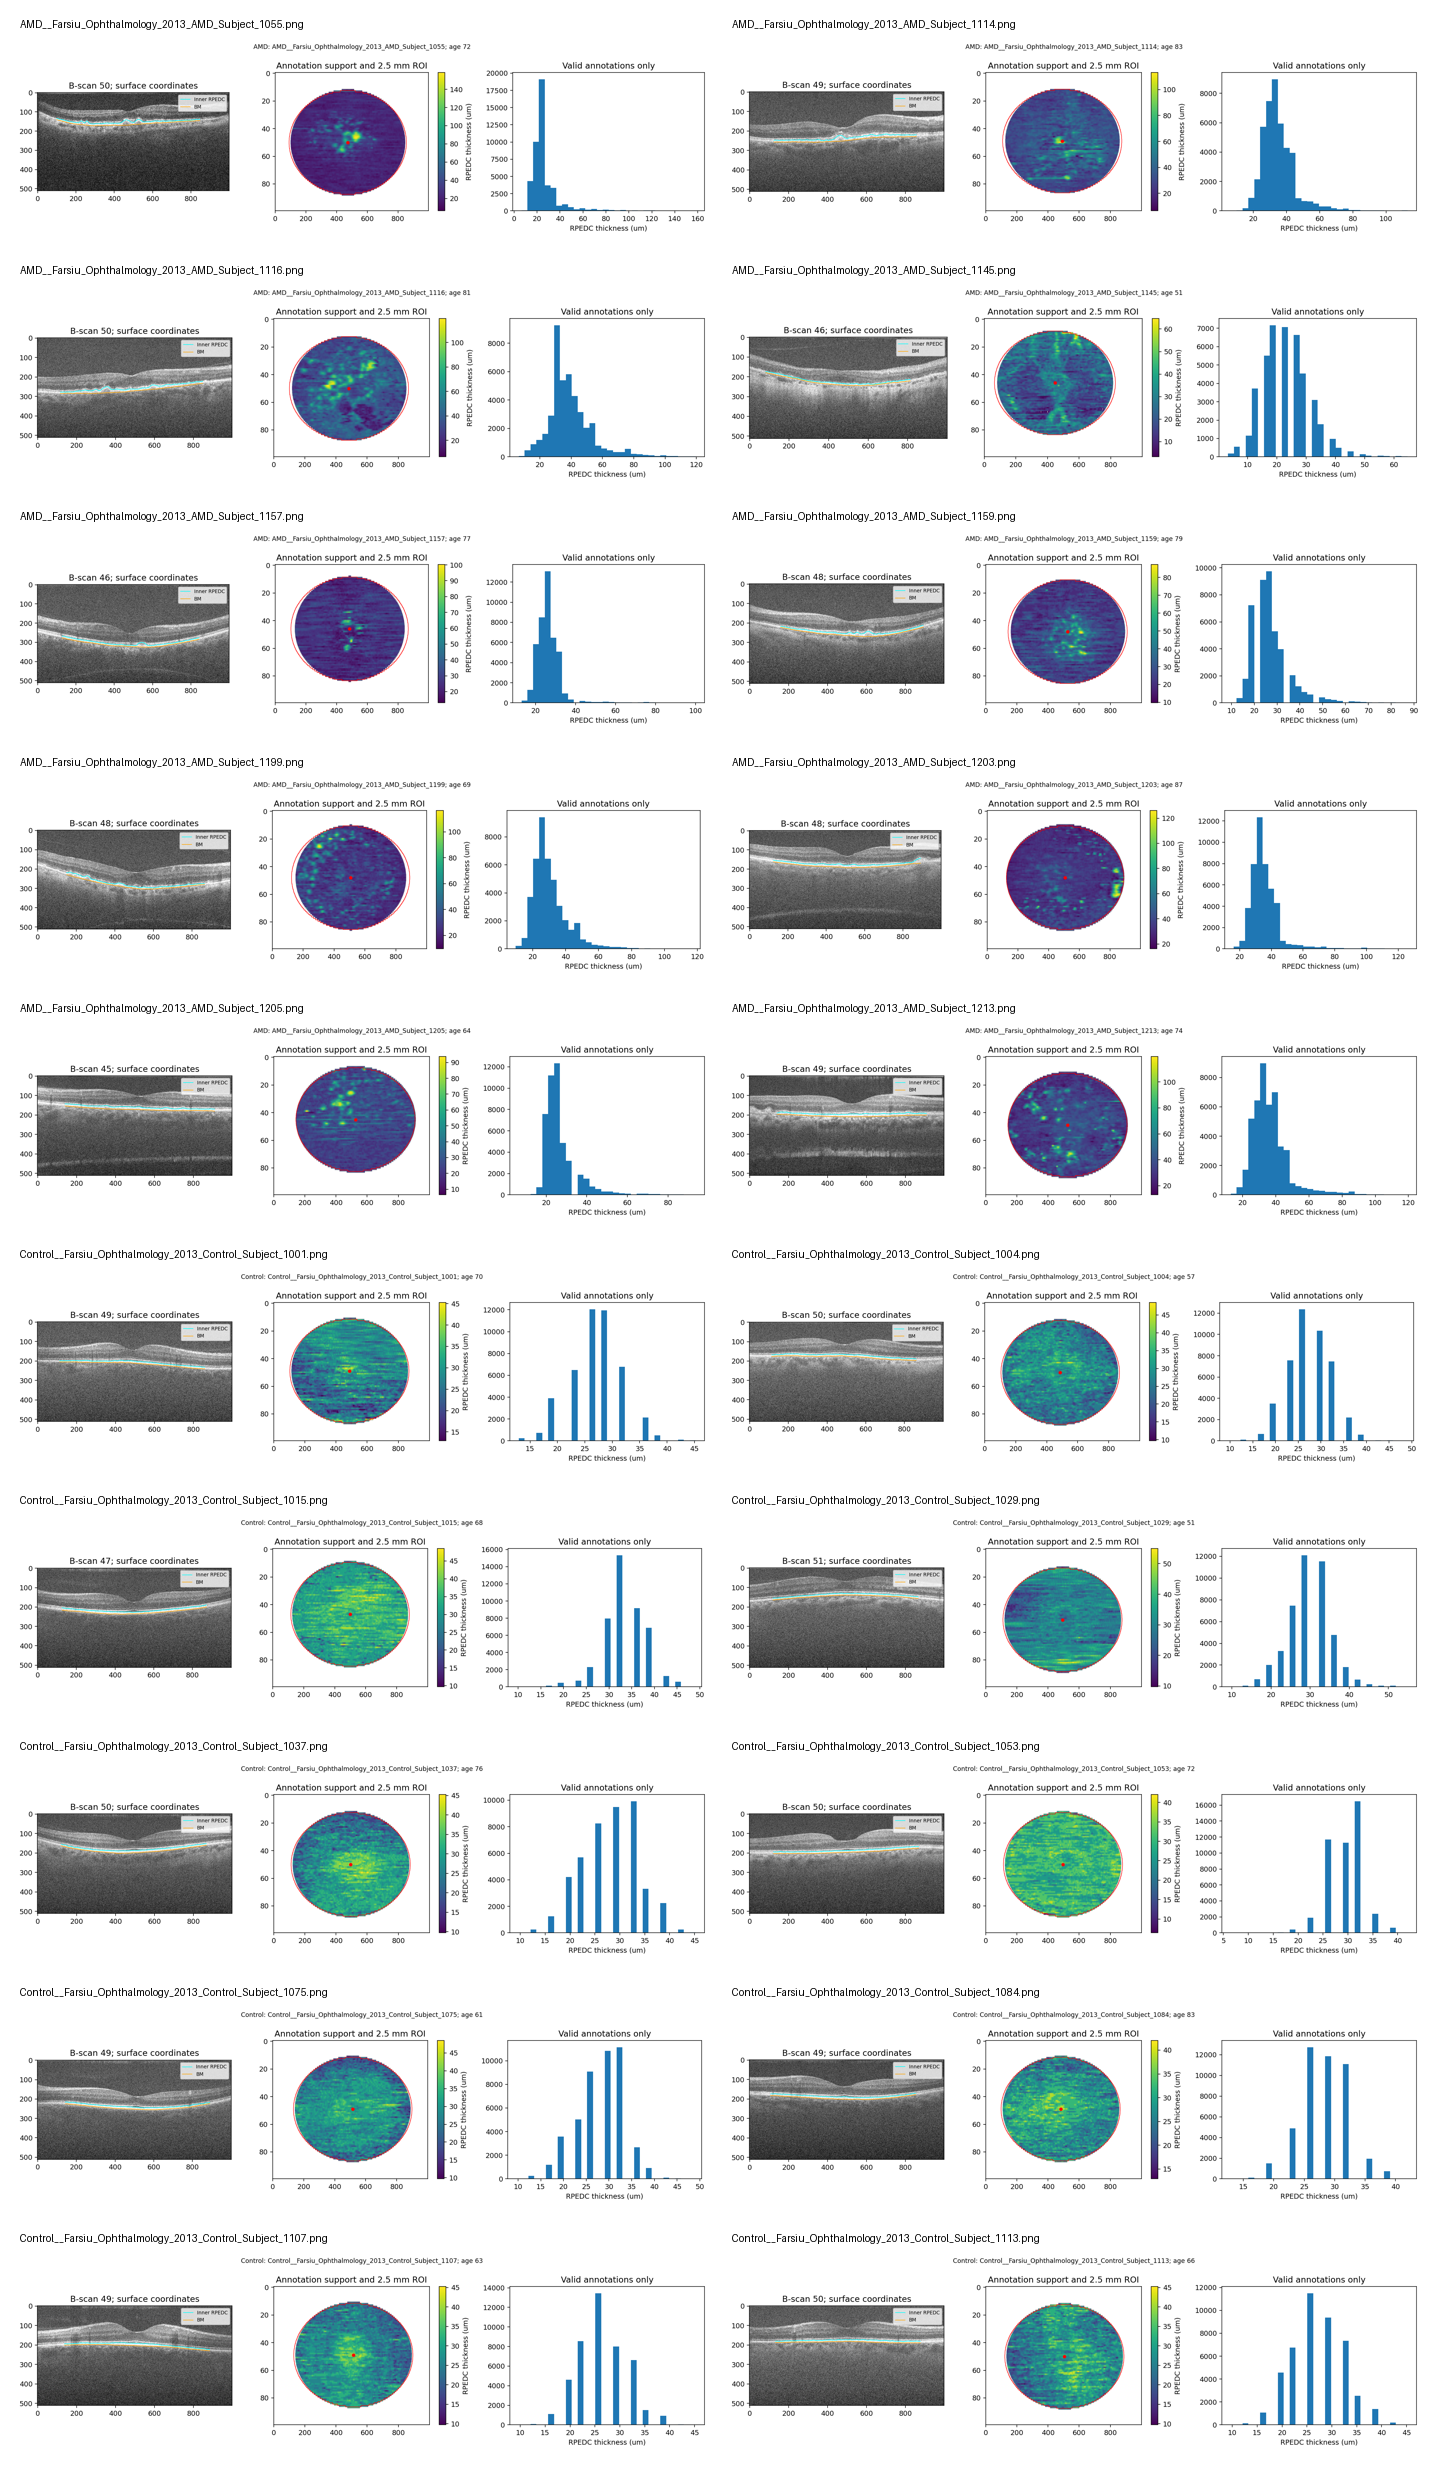

QC panels: 20
QC backup: /content/drive/MyDrive/BOE_OCT/results/qc
QC approval gate: PASS


In [10]:
import math
import shutil
import subprocess
import sys
from IPython.display import display, Image as IPImage
from PIL import Image, ImageOps, ImageDraw

qc_dir = REPO_DIR / "reports" / "boe_qc"
qc_dir.parent.mkdir(parents=True, exist_ok=True)

if RUN_QC:
    pngs = sorted(qc_dir.glob("*.png")) if qc_dir.exists() else []
    if len(pngs) != 20:
        if qc_dir.exists():
            shutil.rmtree(qc_dir)
        subprocess.run(
            [sys.executable, "-m", "src.boe.qc", "--data", str(BOE_DATA), "--out", str(qc_dir), "--per-group", "10"],
            cwd=REPO_DIR,
            check=True,
        )
    pngs = sorted(qc_dir.glob("*.png"))
    assert len(pngs) == 20, f"Expected 20 QC panels, found {len(pngs)}"

    # Create a readable two-column contact sheet for a quick review.
    thumb_w = 700
    margin = 12
    thumbs = []
    for p in pngs:
        im = Image.open(p).convert("RGB")
        new_h = int(im.height * thumb_w / im.width)
        im.thumbnail((thumb_w, new_h))
        canvas = Image.new("RGB", (thumb_w, im.height + 34), "white")
        canvas.paste(im, ((thumb_w - im.width)//2, 28))
        ImageDraw.Draw(canvas).text((8, 6), p.name, fill="black")
        thumbs.append(canvas)

    cols = 2
    rows = math.ceil(len(thumbs) / cols)
    cell_h = max(im.height for im in thumbs)
    sheet = Image.new("RGB", (cols * (thumb_w + margin) + margin, rows * (cell_h + margin) + margin), "white")
    for i, im in enumerate(thumbs):
        r, c = divmod(i, cols)
        sheet.paste(im, (margin + c * (thumb_w + margin), margin + r * (cell_h + margin)))

    contact_sheet = REPO_DIR / "reports" / "boe_qc_contact_sheet.png"
    sheet.save(contact_sheet)
    display(IPImage(filename=str(contact_sheet), width=1200))

    qc_backup = DRIVE_RESULTS / "qc"
    if qc_backup.exists():
        shutil.rmtree(qc_backup)
    shutil.copytree(qc_dir, qc_backup)
    shutil.copy2(contact_sheet, DRIVE_RESULTS / contact_sheet.name)

    print("QC panels:", len(pngs))
    print("QC backup:", qc_backup)
else:
    print("RUN_QC=False, QC generation skipped.")

if not QC_APPROVED:
    raise RuntimeError(
        "QC_APPROVED=False. Review all 20 QC panels, then set QC_APPROVED=True before full training."
    )
print("QC approval gate: PASS")

## 10. Save environment provenance

This records the exact repository commit, package environment, PyTorch/CUDA version, and GPU used for the pilot.

In [11]:
import json
import subprocess
import sys
import torch

ENV_DIR = DRIVE_RESULTS / "environment"
ENV_DIR.mkdir(parents=True, exist_ok=True)

head = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True).strip()
(ENV_DIR / "git_commit.txt").write_text(head + "\n")

with open(ENV_DIR / "pip_freeze.txt", "w") as f:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=f, check=True)
with open(ENV_DIR / "nvidia_smi.txt", "w") as f:
    subprocess.run(["nvidia-smi"], stdout=f, check=True)

env_info = {
    "git_commit": head,
    "pytorch": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "fold": FOLD,
    "seed": SEED,
}
(ENV_DIR / "pytorch_environment.json").write_text(json.dumps(env_info, indent=2) + "\n")
print(json.dumps(env_info, indent=2))

{
  "git_commit": "f4661738bb6869a82fed3c255d7ffa4e98e681fe",
  "pytorch": "2.11.0+cu130",
  "cuda_available": true,
  "cuda_version": "13.0",
  "gpu": "NVIDIA L4",
  "fold": 1,
  "seed": 42
}


## 11. Write the profiling and validation analysis helpers

These helper scripts are generated directly by the notebook.

The thickness term in the supplied trainer is local by A scan: predicted and reference occupancy are summed axially **for each column**, converted to micrometers, and Smooth L1 is applied to each valid column before averaging. It does not merely match a B scan average thickness.

The validation helper below only evaluates subjects with `role == "val"`. It never evaluates Fold 1 calibration or test subjects.

In [12]:
from pathlib import Path
import py_compile

profiler_text = '"""Run the supplied BOE trainer and record runtime/GPU memory."""\nimport json\nimport os\nimport sys\nimport time\nfrom pathlib import Path\n\nREPO = Path("/content/retina-drusen-volume")\nsys.path.insert(0, str(REPO))\nos.chdir(REPO)\n\nimport torch\nfrom src.boe import train\n\nout_idx = sys.argv.index("--out") + 1\nout_dir = Path(sys.argv[out_idx])\n\ngpu_available = torch.cuda.is_available()\nif gpu_available:\n    torch.cuda.empty_cache()\n    torch.cuda.synchronize()\n    torch.cuda.reset_peak_memory_stats()\n\nstart = time.perf_counter()\ntrain.main()\nif gpu_available:\n    torch.cuda.synchronize()\nelapsed = time.perf_counter() - start\n\nstats = {\n    "runtime_seconds": elapsed,\n    "runtime_minutes": elapsed / 60,\n    "gpu": torch.cuda.get_device_name(0) if gpu_available else None,\n    "peak_gpu_allocated_gb": torch.cuda.max_memory_allocated() / 1024**3 if gpu_available else None,\n    "peak_gpu_reserved_gb": torch.cuda.max_memory_reserved() / 1024**3 if gpu_available else None,\n    "gpu_total_memory_gb": torch.cuda.get_device_properties(0).total_memory / 1024**3 if gpu_available else None,\n    "completed": True,\n}\n\nout_dir.mkdir(parents=True, exist_ok=True)\n(out_dir / "resource_usage.json").write_text(json.dumps(stats, indent=2) + "\\n")\n(out_dir / "_SUCCESS.json").write_text(json.dumps(stats, indent=2) + "\\n")\nprint("\\n===== RESOURCE USAGE =====")\nprint(json.dumps(stats, indent=2))\n'
pilot_validate_text = '"""Validation-only BOE pilot measurement evaluation. Never reads cal/test subjects."""\nimport argparse, math\nfrom pathlib import Path\nimport numpy as np\nimport pandas as pd\nimport torch\n\nfrom src.boe.core import (\n    radial_bins, control_profile, age_atlas, paired_volume,\n    fractional_target, digest, write_json\n)\nfrom src.boe.train import build_model, load_fold\nfrom src.boe.evaluate import predict\n\n\ndef center_for(row, mode):\n    if mode == "label":\n        return (float(row.center_z), float(row.center_x))\n    if mode == "scan":\n        return ((float(row.bscans) - 1.0) / 2.0,\n                (float(row.width) - 1.0) / 2.0)\n    raise ValueError(mode)\n\n\ndef dice_from_masks(masks, upper, lower, height):\n    inter = 0.0\n    denom = 0.0\n    for z in range(len(masks)):\n        target, valid = fractional_target(upper[z], lower[z], height)\n        pred = masks[z] & valid[None]\n        truth = (target >= 0.5) & valid[None]\n        inter += (pred & truth).sum()\n        denom += pred.sum() + truth.sum()\n    return float((2 * inter + 1e-6) / (denom + 1e-6))\n\n\ndef boundary_metrics(masks, upper, lower, height, axial_um):\n    upper_err, lower_err = [], []\n    valid_cols = 0\n    predicted_cols = 0\n\n    for z in range(masks.shape[0]):\n        _, valid = fractional_target(upper[z], lower[z], height)\n\n        for x in np.flatnonzero(valid):\n            valid_cols += 1\n            ys = np.flatnonzero(masks[z, :, x])\n\n            if not len(ys):\n                continue\n\n            predicted_cols += 1\n\n            # Occupied image cells are zero-based.\n            pred_upper = float(ys[0])\n            pred_lower = float(ys[-1] + 1)\n\n            # Duke boundaries are stored as MATLAB one-based coordinates.\n            ref_upper = float(upper[z, x] - 1.0)\n            ref_lower = float(lower[z, x] - 1.0)\n\n            upper_err.append(abs(pred_upper - ref_upper) * axial_um)\n            lower_err.append(abs(pred_lower - ref_lower) * axial_um)\n\n    if not upper_err:\n        return {\n            "inner_rpedc_mae_um": np.nan,\n            "bm_mae_um": np.nan,\n            "boundary_mae_um": np.nan,\n            "boundary_coverage": 0.0,\n        }\n\n    u = float(np.mean(upper_err))\n    l = float(np.mean(lower_err))\n\n    return {\n        "inner_rpedc_mae_um": u,\n        "bm_mae_um": l,\n        "boundary_mae_um": (u + l) / 2.0,\n        "boundary_coverage": predicted_cols / max(valid_cols, 1),\n    }\n\n\ndef all_thickness_metrics(pred, ref):\n    valid = np.isfinite(ref) & np.isfinite(pred)\n\n    if not valid.any():\n        return {\n            "thickness_mae_all_um": np.nan,\n            "thickness_bias_all_um": np.nan,\n        }\n\n    delta = pred[valid] - ref[valid]\n\n    return {\n        "thickness_mae_all_um": float(np.abs(delta).mean()),\n        "thickness_bias_all_um": float(delta.mean()),\n    }\n\n\ndef build_controls(frame, center_mode, radius_mm, bin_mm):\n    n_bins = math.ceil(radius_mm / bin_mm)\n    controls = []\n\n    train_controls = frame[\n        (frame.role == "train") & (frame.group == "Control")\n    ]\n\n    for row in train_controls.itertuples():\n        spacing = (row.axial_um, row.lateral_um, row.bscan_um)\n\n        with np.load(Path(row.path) / "labels.npz") as labels:\n            gt = labels["thickness"]\n\n        bins = radial_bins(\n            gt.shape,\n            center_for(row, center_mode),\n            spacing,\n            radius_mm,\n            bin_mm,\n        )\n\n        controls.append({\n            "subject": row.subject,\n            "age": row.age,\n            "profile": control_profile(gt, bins, n_bins),\n        })\n\n    return controls\n\n\ndef main():\n    p = argparse.ArgumentParser(description=__doc__)\n\n    p.add_argument("--data", required=True)\n    p.add_argument("--checkpoint", required=True)\n    p.add_argument("--out", required=True)\n\n    p.add_argument("--k-values", nargs="+", type=float, default=[2.0, 3.0, 4.0])\n    p.add_argument("--radius-mm", type=float, default=2.5)\n    p.add_argument("--bin-mm", type=float, default=0.25)\n    p.add_argument("--min-controls", type=int, default=5)\n    p.add_argument("--min-coverage", type=float, default=0.8)\n\n    args = p.parse_args()\n\n    out = Path(args.out)\n\n    if (out / "validation_measurements.csv").exists():\n        raise FileExistsError("Use a fresh output directory")\n\n    out.mkdir(parents=True, exist_ok=True)\n    (out / "predictions").mkdir(exist_ok=True)\n\n    checkpoint = torch.load(\n        args.checkpoint,\n        map_location="cpu",\n        weights_only=True,\n    )\n\n    config = checkpoint["config"]\n\n    # Refuse to evaluate a checkpoint on a different prepared cohort.\n    for file, key in [\n        ("subjects.csv", "cohort_sha256"),\n        ("splits.csv", "splits_sha256"),\n    ]:\n        if digest(Path(args.data) / file) != config[key]:\n            raise ValueError(f"Checkpoint belongs to a different {file}")\n\n    device = torch.device(\n        "cuda" if torch.cuda.is_available() else "cpu"\n    )\n\n    model = build_model(\n        config["architecture"],\n        config["width"],\n    )\n\n    model.load_state_dict(checkpoint["model_state_dict"])\n    model.to(device).eval()\n\n    frame = load_fold(args.data, config["fold"])\n\n    # The normal atlas is built ONLY from model-training controls.\n    # Build it independently for each center definition.\n    controls = {\n        mode: build_controls(\n            frame,\n            mode,\n            args.radius_mm,\n            args.bin_mm,\n        )\n        for mode in ("label", "scan")\n    }\n\n    if any(len(v) < args.min_controls for v in controls.values()):\n        raise ValueError("Too few model-training controls")\n\n    rows = []\n\n    # IMPORTANT: validation subjects only.\n    # This script never evaluates calibration or outer-test subjects.\n    val_frame = frame[frame.role == "val"]\n\n    for row in val_frame.itertuples():\n        spacing = (\n            row.axial_um,\n            row.lateral_um,\n            row.bscan_um,\n        )\n\n        images = np.load(\n            Path(row.path) / "images.npy",\n            mmap_mode="r",\n        )\n\n        with np.load(Path(row.path) / "labels.npz") as labels:\n            gt = labels["thickness"]\n            upper = labels["upper"]\n            lower = labels["lower"]\n\n        pred, masks = predict(\n            model,\n            images,\n            config["context"],\n            row.axial_um,\n            device,\n        )\n\n        np.save(\n            out / "predictions" / f"{row.subject}_thickness_um.npy",\n            pred,\n        )\n\n        dice = dice_from_masks(\n            masks,\n            upper,\n            lower,\n            images.shape[1],\n        )\n\n        bmet = boundary_metrics(\n            masks,\n            upper,\n            lower,\n            images.shape[1],\n            row.axial_um,\n        )\n\n        tmet = all_thickness_metrics(pred, gt)\n\n        label_center = center_for(row, "label")\n        scan_center = center_for(row, "scan")\n\n        center_shift_mm = float(\n            np.hypot(\n                (label_center[0] - scan_center[0])\n                * row.bscan_um / 1000.0,\n                (label_center[1] - scan_center[1])\n                * row.lateral_um / 1000.0,\n            )\n        )\n\n        for center_mode in ("label", "scan"):\n            bins = radial_bins(\n                gt.shape,\n                center_for(row, center_mode),\n                spacing,\n                args.radius_mm,\n                args.bin_mm,\n            )\n\n            mean, std, atlas_info = age_atlas(\n                controls[center_mode],\n                row.age,\n                args.min_controls,\n            )\n\n            for k in args.k_values:\n                result = paired_volume(\n                    pred,\n                    gt,\n                    mean,\n                    std,\n                    bins,\n                    spacing,\n                    k,\n                    args.min_coverage,\n                )\n\n                rows.append({\n                    "subject": row.subject,\n                    "group": row.group,\n                    "role": "val",\n                    "fold": config["fold"],\n                    "seed": config["seed"],\n                    "context": config["context"],\n                    "thickness_weight": config["thickness_weight"],\n                    "center_mode": center_mode,\n                    "center_shift_mm": center_shift_mm,\n                    "k": k,\n                    "val_subject_dice": dice,\n                    **bmet,\n                    **tmet,\n                    **atlas_info,\n                    **result,\n                })\n\n        print(row.subject, flush=True)\n\n    results = pd.DataFrame(rows)\n\n    results["signed_error_mm3"] = (\n        results.predicted_volume_mm3\n        - results.reference_volume_mm3\n    )\n\n    results["absolute_error_mm3"] = (\n        results.signed_error_mm3.abs()\n    )\n\n    results.to_csv(\n        out / "validation_measurements.csv",\n        index=False,\n    )\n\n    write_json(\n        out / "validation_evaluation.json",\n        {\n            "checkpoint": str(args.checkpoint),\n            "fold": config["fold"],\n            "seed": config["seed"],\n            "role": "val_only",\n            "test_set_accessed": False,\n            "center_modes": [\n                "label_assisted_annotation_support_center",\n                "scan_center",\n            ],\n            "k_values": args.k_values,\n            "boundary_definition":\n                "0.5 hard-mask first occupied cell = upper; "\n                "last occupied cell + 1 = lower",\n            "note":\n                "Training-control-only atlas rebuilt separately "\n                "for each center mode.",\n        },\n    )\n\n    print(\n        results.groupby(\n            ["center_mode", "group", "k"]\n        )[\n            [\n                "val_subject_dice",\n                "boundary_mae_um",\n                "thickness_mae_all_um",\n                "absolute_error_mm3",\n                "signed_error_mm3",\n            ]\n        ].mean()\n    )\n\n\nif __name__ == "__main__":\n    main()\n'
pilot_compare_text = '"""Compare three BOE validation-only pilot arms with patient-level bootstrap CIs."""\nimport argparse\nfrom pathlib import Path\n\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nfrom scipy.stats import spearmanr\n\n\ndef finite(values):\n    x = np.asarray(values, float)\n    return x[np.isfinite(x)]\n\n\ndef boot_mean_ci(values, rng, n=5000):\n    x = finite(values)\n    if len(x) < 2:\n        return (np.nan, np.nan)\n    means = rng.choice(x, size=(n, len(x)), replace=True).mean(axis=1)\n    return tuple(np.quantile(means, [0.025, 0.975]))\n\n\ndef safe_spearman(x, y):\n    x = np.asarray(x, float)\n    y = np.asarray(y, float)\n    keep = np.isfinite(x) & np.isfinite(y)\n    if keep.sum() < 3 or np.unique(x[keep]).size < 2 or np.unique(y[keep]).size < 2:\n        return np.nan, np.nan, int(keep.sum())\n    rho, p = spearmanr(x[keep], y[keep])\n    return float(rho), float(p), int(keep.sum())\n\n\ndef main():\n    p = argparse.ArgumentParser(description=__doc__)\n    p.add_argument("--baseline", required=True)\n    p.add_argument("--context", required=True)\n    p.add_argument("--thickness", required=True)\n    p.add_argument("--out", required=True)\n    p.add_argument("--k", type=float, default=3.0)\n    p.add_argument("--center", choices=["label", "scan"], default="label")\n    p.add_argument("--bootstrap", type=int, default=5000)\n    args = p.parse_args()\n\n    out = Path(args.out)\n    out.mkdir(parents=True, exist_ok=True)\n    rng = np.random.default_rng(2026)\n\n    paths = {\n        "baseline": args.baseline,\n        "context": args.context,\n        "thickness": args.thickness,\n    }\n\n    frames = {}\n    summary_rows = []\n    ba_rows = []\n    burden_rows = []\n    support_rows = []\n\n    for name, path in paths.items():\n        d0 = pd.read_csv(path)\n        selected = d0[(d0.center_mode == args.center) & np.isclose(d0.k, args.k)].copy()\n        for (group, status), sg in selected.groupby(["group", "status"]):\n            support_rows.append({\n                "model": name,\n                "group": group,\n                "status": status,\n                "n": len(sg),\n                "center_mode": args.center,\n                "k": args.k,\n            })\n        d = selected[selected.status == "ok"].copy()\n\n        if d.subject.duplicated().any():\n            raise ValueError(f"Duplicate subjects in {name}")\n        if not (d.role == "val").all():\n            raise ValueError(f"Non-validation rows detected in {name}")\n\n        frames[name] = d\n\n        for group, g in d.groupby("group"):\n            metric_map = {\n                "dice": g.val_subject_dice.to_numpy(),\n                "boundary_mae_um": g.boundary_mae_um.to_numpy(),\n                "boundary_coverage": g.boundary_coverage.to_numpy(),\n                "thickness_mae_um": g.thickness_mae_all_um.to_numpy(),\n                "thickness_bias_um": g.thickness_bias_all_um.to_numpy(),\n                "reference_volume_mm3": g.reference_volume_mm3.to_numpy(),\n                "predicted_volume_mm3": g.predicted_volume_mm3.to_numpy(),\n                "volume_abs_error_mm3": g.absolute_error_mm3.to_numpy(),\n                "volume_signed_error_mm3": g.signed_error_mm3.to_numpy(),\n            }\n\n            total_group = int((selected.group == group).sum())\n            row = {\n                "model": name,\n                "group": group,\n                "n_total": total_group,\n                "n_ok": len(g),\n                "n_excluded_support": total_group - len(g),\n                "center_mode": args.center,\n                "k": args.k,\n            }\n            for key, vals in metric_map.items():\n                vals_f = finite(vals)\n                row[key] = float(np.mean(vals_f)) if len(vals_f) else np.nan\n                lo, hi = boot_mean_ci(vals, rng, args.bootstrap)\n                row[key + "_ci_low"] = lo\n                row[key + "_ci_high"] = hi\n            summary_rows.append(row)\n\n            # Bland-Altman statistics and plot.\n            meanv = (g.predicted_volume_mm3 + g.reference_volume_mm3) / 2.0\n            diff = g.signed_error_mm3\n            diff_f = finite(diff)\n            bias = float(np.mean(diff_f)) if len(diff_f) else np.nan\n            sd = float(np.std(diff_f, ddof=1)) if len(diff_f) > 1 else np.nan\n            lower = bias - 1.96 * sd if np.isfinite(sd) else np.nan\n            upper = bias + 1.96 * sd if np.isfinite(sd) else np.nan\n            ba_rows.append({\n                "model": name,\n                "group": group,\n                "n": len(diff_f),\n                "center_mode": args.center,\n                "k": args.k,\n                "bias_mm3": bias,\n                "loa_lower_mm3": lower,\n                "loa_upper_mm3": upper,\n            })\n\n            fig, ax = plt.subplots(figsize=(6, 4))\n            ax.scatter(meanv, diff, s=24)\n            ax.axhline(bias, ls="--", label=f"bias={bias:.4g}")\n            if np.isfinite(sd):\n                ax.axhline(upper, ls=":", label="+1.96 SD")\n                ax.axhline(lower, ls=":", label="-1.96 SD")\n            ax.set_xlabel("Mean predicted/reference excess RPEDC volume (mm³)")\n            ax.set_ylabel("Predicted - reference volume (mm³)")\n            ax.set_title(f"{name}: {group} Bland-Altman, k={args.k:g}, center={args.center}")\n            ax.legend(fontsize=8)\n            fig.tight_layout()\n            fig.savefig(out / f"bland_altman_{name}_{group}.png", dpi=180)\n            plt.close(fig)\n\n            # AMD lesion-burden relationship.\n            if group == "AMD":\n                rho, pvalue, n_corr = safe_spearman(\n                    g.reference_volume_mm3,\n                    g.absolute_error_mm3,\n                )\n                burden_rows.append({\n                    "model": name,\n                    "group": group,\n                    "n": n_corr,\n                    "center_mode": args.center,\n                    "k": args.k,\n                    "spearman_rho": rho,\n                    "p_value": pvalue,\n                })\n                fig, ax = plt.subplots(figsize=(6, 4))\n                ax.scatter(g.reference_volume_mm3, g.absolute_error_mm3, s=24)\n                ax.set_xlabel("Reference excess RPEDC volume (mm³)")\n                ax.set_ylabel("Absolute volume error (mm³)")\n                title_rho = "NA" if not np.isfinite(rho) else f"{rho:.2f}"\n                ax.set_title(f"{name}: AMD burden vs error; Spearman rho={title_rho}")\n                fig.tight_layout()\n                fig.savefig(out / f"burden_error_{name}_AMD.png", dpi=180)\n                plt.close(fig)\n\n        ranked = d.sort_values("absolute_error_mm3")\n        n_examples = min(3, len(ranked))\n        examples = pd.concat([\n            ranked.head(n_examples).assign(example="accurate"),\n            ranked.tail(n_examples).assign(example="largest_error"),\n        ])\n        examples.to_csv(out / f"examples_{name}.csv", index=False)\n\n    pd.DataFrame(summary_rows).to_csv(out / "model_summary.csv", index=False)\n    pd.DataFrame(support_rows).to_csv(out / "support_status.csv", index=False)\n    pd.DataFrame(ba_rows).to_csv(out / "bland_altman_stats.csv", index=False)\n    pd.DataFrame(burden_rows).to_csv(out / "burden_error_correlations.csv", index=False)\n\n    # Paired patient-level comparisons and direct Dice-change vs error-change relationship.\n    comparison_rows = []\n    delta_rows = []\n    pairs = [\n        ("context", "baseline"),\n        ("thickness", "context"),\n        ("thickness", "baseline"),\n    ]\n\n    for a, b in pairs:\n        merged = frames[a].merge(\n            frames[b],\n            on=["subject", "group"],\n            suffixes=("_a", "_b"),\n            validate="one_to_one",\n        )\n\n        for group, g in merged.groupby("group"):\n            for metric in [\n                "val_subject_dice",\n                "absolute_error_mm3",\n                "thickness_mae_all_um",\n                "boundary_mae_um",\n            ]:\n                delta = g[metric + "_a"].to_numpy() - g[metric + "_b"].to_numpy()\n                lo, hi = boot_mean_ci(delta, rng, args.bootstrap)\n                comparison_rows.append({\n                    "model_a": a,\n                    "model_b": b,\n                    "group": group,\n                    "metric": metric,\n                    "n": int(np.isfinite(delta).sum()),\n                    "mean_difference_a_minus_b": float(np.nanmean(delta)),\n                    "ci95_low": lo,\n                    "ci95_high": hi,\n                })\n\n            dice_delta = g.val_subject_dice_a.to_numpy() - g.val_subject_dice_b.to_numpy()\n            for metric in [\n                "absolute_error_mm3",\n                "thickness_mae_all_um",\n                "boundary_mae_um",\n            ]:\n                error_delta = g[metric + "_a"].to_numpy() - g[metric + "_b"].to_numpy()\n                rho, pvalue, n_corr = safe_spearman(dice_delta, error_delta)\n                delta_rows.append({\n                    "model_a": a,\n                    "model_b": b,\n                    "group": group,\n                    "error_metric": metric,\n                    "n": n_corr,\n                    "spearman_rho_dDice_vs_dError": rho,\n                    "p_value": pvalue,\n                    "interpretation": "negative rho means Dice improvement tends to accompany error reduction",\n                })\n\n    pd.DataFrame(comparison_rows).to_csv(out / "paired_model_comparisons.csv", index=False)\n    pd.DataFrame(delta_rows).to_csv(out / "paired_dice_error_relationship.csv", index=False)\n\n    # Within-model descriptive Dice/error associations (kept separate; no pooled repeated-subject analysis).\n    correlation_rows = []\n    for name, d in frames.items():\n        for group, g in d.groupby("group"):\n            for metric in ["thickness_mae_all_um", "absolute_error_mm3", "boundary_mae_um"]:\n                rho, pvalue, n_corr = safe_spearman(g.val_subject_dice, g[metric])\n                correlation_rows.append({\n                    "model": name,\n                    "group": group,\n                    "metric": metric,\n                    "n": n_corr,\n                    "spearman_rho": rho,\n                    "p_value": pvalue,\n                })\n    pd.DataFrame(correlation_rows).to_csv(out / "dice_measurement_correlations.csv", index=False)\n\n    # Annotation-center vs scan-center sensitivity. Read unfiltered source files because both centers are needed.\n    center_rows = []\n    for name, path in paths.items():\n        d = pd.read_csv(path)\n        d = d[np.isclose(d.k, args.k) & (d.status == "ok")].copy()\n        label = d[d.center_mode == "label"]\n        scan = d[d.center_mode == "scan"]\n        merged = label.merge(\n            scan,\n            on=["subject", "group"],\n            suffixes=("_label", "_scan"),\n            validate="one_to_one",\n        )\n        for group, g in merged.groupby("group"):\n            center_rows.append({\n                "model": name,\n                "group": group,\n                "n": len(g),\n                "mean_center_shift_mm": float(g.center_shift_mm_label.mean()),\n                "median_center_shift_mm": float(g.center_shift_mm_label.median()),\n                "mean_abs_pred_volume_change_mm3": float(np.abs(\n                    g.predicted_volume_mm3_scan - g.predicted_volume_mm3_label\n                ).mean()),\n                "mean_abs_reference_volume_change_mm3": float(np.abs(\n                    g.reference_volume_mm3_scan - g.reference_volume_mm3_label\n                ).mean()),\n            })\n    pd.DataFrame(center_rows).to_csv(out / "center_sensitivity.csv", index=False)\n\n    summary_df = pd.DataFrame(summary_rows)\n    comparisons_df = pd.DataFrame(comparison_rows)\n    print(summary_df.to_string(index=False))\n    print("\\nPaired comparisons:")\n    print(comparisons_df.to_string(index=False))\n\n\nif __name__ == "__main__":\n    main()\n'
pilot_examples_text = '"""Create validation pilot examples with boundary overlays and thickness maps."""\nimport argparse\nfrom pathlib import Path\n\nimport matplotlib\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\n\nfrom src.boe.train import build_model\nfrom src.boe.evaluate import predict\nfrom src.boe.core import fractional_target\n\n\ndef hard_boundaries(mask):\n    _, w = mask.shape\n    upper = np.full(w, np.nan, dtype=float)\n    lower = np.full(w, np.nan, dtype=float)\n    for x in range(w):\n        ys = np.flatnonzero(mask[:, x])\n        if len(ys):\n            upper[x] = ys[0]\n            lower[x] = ys[-1] + 1\n    return upper, lower\n\n\ndef main():\n    p = argparse.ArgumentParser(description=__doc__)\n    p.add_argument("--data", required=True)\n    p.add_argument("--checkpoint", required=True)\n    p.add_argument("--examples-csv", required=True)\n    p.add_argument("--out", required=True)\n    args = p.parse_args()\n\n    out = Path(args.out)\n    out.mkdir(parents=True, exist_ok=True)\n\n    subjects = pd.read_csv(Path(args.data) / "subjects.csv").set_index("subject")\n    examples = pd.read_csv(args.examples_csv)\n\n    checkpoint = torch.load(args.checkpoint, map_location="cpu", weights_only=True)\n    config = checkpoint["config"]\n    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n    model = build_model(config["architecture"], config["width"])\n    model.load_state_dict(checkpoint["model_state_dict"])\n    model.to(device).eval()\n\n    for ex in examples.itertuples():\n        row = subjects.loc[ex.subject]\n        images = np.load(Path(row.path) / "images.npy", mmap_mode="r")\n        with np.load(Path(row.path) / "labels.npz") as labels:\n            ref_thickness = labels["thickness"]\n            upper = labels["upper"]\n            lower = labels["lower"]\n\n        pred_thickness, masks = predict(\n            model, images, config["context"], row.axial_um, device\n        )\n\n        difference = pred_thickness - ref_thickness\n        with np.errstate(invalid="ignore"):\n            per_scan_mae = np.nanmean(np.abs(difference), axis=1)\n        z = int(np.nanargmax(per_scan_mae)) if np.isfinite(per_scan_mae).any() else int(\n            np.clip(round(row.center_z), 0, len(images) - 1)\n        )\n\n        pred_upper, pred_lower = hard_boundaries(masks[z])\n        _, valid = fractional_target(upper[z], lower[z], images.shape[1])\n        x = np.arange(images.shape[2])\n        ref_upper = upper[z] - 1.0\n        ref_lower = lower[z] - 1.0\n\n        finite_thickness = np.concatenate([\n            ref_thickness[np.isfinite(ref_thickness)],\n            pred_thickness[np.isfinite(pred_thickness)],\n        ])\n        vmin = float(np.quantile(finite_thickness, 0.01)) if len(finite_thickness) else None\n        vmax = float(np.quantile(finite_thickness, 0.99)) if len(finite_thickness) else None\n        diff_finite = np.abs(difference[np.isfinite(difference)])\n        diff_lim = float(np.quantile(diff_finite, 0.99)) if len(diff_finite) else None\n\n        fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))\n        axes[0].imshow(images[z], cmap="gray", aspect="auto")\n        axes[0].plot(x[valid], ref_upper[valid], linewidth=1, label="Reference inner RPEDC")\n        axes[0].plot(x[valid], ref_lower[valid], linewidth=1, label="Reference BM")\n        finite_pred = np.isfinite(pred_upper)\n        axes[0].plot(x[finite_pred], pred_upper[finite_pred], linewidth=1, linestyle="--", label="Predicted upper")\n        axes[0].plot(x[finite_pred], pred_lower[finite_pred], linewidth=1, linestyle="--", label="Predicted lower")\n        axes[0].set_title(f"B-scan {z}: largest thickness-error slice")\n        axes[0].legend(fontsize=7)\n\n        im1 = axes[1].imshow(ref_thickness, aspect="auto", vmin=vmin, vmax=vmax)\n        axes[1].set_title("Reference RPEDC thickness")\n        fig.colorbar(im1, ax=axes[1], label="µm")\n\n        im2 = axes[2].imshow(pred_thickness, aspect="auto", vmin=vmin, vmax=vmax)\n        axes[2].set_title("Predicted RPEDC thickness")\n        fig.colorbar(im2, ax=axes[2], label="µm")\n\n        im3 = axes[3].imshow(\n            difference,\n            aspect="auto",\n            vmin=(-diff_lim if diff_lim else None),\n            vmax=(diff_lim if diff_lim else None),\n        )\n        axes[3].set_title("Prediction - reference")\n        fig.colorbar(im3, ax=axes[3], label="µm")\n\n        fig.suptitle(\n            f"{ex.subject} | {ex.example} | volume abs. error = {ex.absolute_error_mm3:.6f} mm³"\n        )\n        fig.tight_layout()\n        fig.savefig(out / f"{ex.example}__{ex.subject}.png", dpi=180)\n        plt.close(fig)\n        print(ex.subject, ex.example, flush=True)\n\n\nif __name__ == "__main__":\n    main()\n'

(PROFILER_PATH := Path("/content/run_boe_profiled.py")).write_text(profiler_text)
(REPO_DIR / "pilot_validate.py").write_text(pilot_validate_text)
(REPO_DIR / "pilot_compare.py").write_text(pilot_compare_text)
(REPO_DIR / "pilot_examples.py").write_text(pilot_examples_text)

for p in [PROFILER_PATH, REPO_DIR / "pilot_validate.py", REPO_DIR / "pilot_compare.py", REPO_DIR / "pilot_examples.py"]:
    py_compile.compile(str(p), doraise=True)
    print("Compiled:", p)

print("Helper scripts ready.")

Compiled: /content/run_boe_profiled.py
Compiled: /content/retina-drusen-volume/pilot_validate.py
Compiled: /content/retina-drusen-volume/pilot_compare.py
Compiled: /content/retina-drusen-volume/pilot_examples.py
Helper scripts ready.


## 12. Restart safe training helper

A completed arm is immediately copied to Drive. On a later Colab runtime, the helper restores completed arms and skips retraining them.

If an arm was interrupted before `_SUCCESS.json` was written, the incomplete directory is archived locally and that arm starts again from epoch 1. This preserves the supplied trainer unchanged.

In [13]:
import datetime
import json
import os
import shlex
import shutil
import subprocess
import sys
from pathlib import Path

ARMS = {
    "baseline": {"context": "2d", "thickness_weight": 0.0},
    "context": {"context": "2p5d", "thickness_weight": 0.0},
    "thickness": {"context": "2p5d", "thickness_weight": 0.1},
}


def _success(path):
    return (Path(path) / "_SUCCESS.json").exists() and (Path(path) / "best.pt").exists()


def restore_completed_arm(arm, local_root, drive_root):
    local = Path(local_root) / arm
    remote = Path(drive_root) / arm
    if _success(local):
        return local
    if _success(remote):
        if local.exists():
            shutil.rmtree(local)
        local.parent.mkdir(parents=True, exist_ok=True)
        shutil.copytree(remote, local)
        print(f"Restored completed {arm} from Drive")
    return local


def archive_incomplete(path):
    path = Path(path)
    if not path.exists() or _success(path):
        return
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    archive_dir = path.parent / "_incomplete"
    archive_dir.mkdir(parents=True, exist_ok=True)
    dest = archive_dir / f"{path.name}_{stamp}"
    shutil.move(str(path), str(dest))
    print("Archived incomplete run to:", dest)


def run_training_arm(arm, local_root, drive_root, epochs):
    if arm not in ARMS:
        raise KeyError(arm)

    local_root = Path(local_root)
    drive_root = Path(drive_root)
    local_root.mkdir(parents=True, exist_ok=True)
    drive_root.mkdir(parents=True, exist_ok=True)

    local = restore_completed_arm(arm, local_root, drive_root)
    if _success(local):
        print(f"SKIP: {arm} is already complete")
        return local

    archive_incomplete(local)
    cfg = ARMS[arm]
    cmd = [
        sys.executable, str(PROFILER_PATH),
        "--data", str(BOE_DATA),
        "--out", str(local),
        "--fold", str(FOLD),
        "--seed", str(SEED),
        "--context", cfg["context"],
        "--thickness-weight", str(cfg["thickness_weight"]),
        "--epochs", str(epochs),
        "--patience", str(PATIENCE),
        "--batch-size", str(BATCH_SIZE),
        "--val-batch-size", str(VAL_BATCH_SIZE),
        "--workers", str(WORKERS),
        "--lr", str(LEARNING_RATE),
        "--amp", str(AMP_MODE),
        "--prefetch-factor", str(PREFETCH_FACTOR),
        "--cache-subjects", str(CACHE_SUBJECTS),
    ]

    if FAST_CUDNN:
        cmd.append("--fast-cudnn")
    if CHANNELS_LAST:
        cmd.append("--channels-last")
    if PERSISTENT_WORKERS:
        cmd.append("--persistent-workers")
    print("$", shlex.join(cmd))
    subprocess.run(cmd, cwd=REPO_DIR, check=True)

    if not _success(local):
        raise RuntimeError(f"{arm} finished without a valid success marker/checkpoint")

    remote = drive_root / arm
    if remote.exists():
        shutil.rmtree(remote)
    shutil.copytree(local, remote)
    print(f"Backed up completed {arm} to {remote}")
    return local

## 12B. One epoch fast throughput check

This runs only the 2D baseline for one epoch with the exact fast settings that will be used in all three full arms. It confirms that batch size 8 fits GPU memory and reports the new epoch time before the long run starts.


In [14]:
SPEED_LOCAL = REPO_DIR / "runs" / "speed_test_fast_bs8"
SPEED_DRIVE = DRIVE_RESULTS / "speed_test_fast_bs8"

if RUN_SPEED_TEST:
    if SPEED_LOCAL.exists():
        shutil.rmtree(SPEED_LOCAL)
    if SPEED_DRIVE.exists():
        shutil.rmtree(SPEED_DRIVE)

    print("Running one optimized baseline epoch...")
    run_training_arm(
        "baseline",
        SPEED_LOCAL,
        SPEED_DRIVE,
        epochs=1,
    )

    speed_run = SPEED_LOCAL / "baseline"
    usage = json.loads((speed_run / "resource_usage.json").read_text())
    h = pd.read_csv(speed_run / "history.csv")

    display(pd.DataFrame([{
        "batch_size": BATCH_SIZE,
        "val_batch_size": VAL_BATCH_SIZE,
        "amp": AMP_MODE,
        "runtime_min": usage["runtime_minutes"],
        "peak_allocated_GB": usage["peak_gpu_allocated_gb"],
        "peak_reserved_GB": usage["peak_gpu_reserved_gb"],
        "val_subject_dice": h.iloc[-1]["val_subject_dice"],
        "gpu": usage["gpu"],
    }]))

    if usage["runtime_minutes"] > 12:
        print(
            "NOTE: optimized epoch is still >12 minutes. "
            "The bottleneck may be the native-resolution workload rather than Python/DataLoader overhead."
        )
else:
    print("RUN_SPEED_TEST=False, throughput check skipped.")


Running one optimized baseline epoch...
$ /usr/bin/python3 /content/run_boe_profiled.py --data /content/BOE_OCT/data/boe_duke --out /content/retina-drusen-volume/runs/speed_test_fast_bs8/baseline --fold 1 --seed 42 --context 2d --thickness-weight 0.0 --epochs 1 --patience 10 --batch-size 8 --val-batch-size 16 --workers 4 --lr 0.0003 --amp auto --prefetch-factor 2 --cache-subjects 8 --fast-cudnn --channels-last --persistent-workers
Backed up completed baseline to /content/drive/MyDrive/BOE_OCT/results/speed_test_fast_bs8/baseline


,batch_size,val_batch_size,amp,runtime_min,peak_allocated_GB,peak_reserved_GB,val_subject_dice,gpu
0,8,16,auto,13.397892,9.321315,11.027344,0.89497,NVIDIA L4


NOTE: optimized epoch is still >12 minutes. The bottleneck may be the native-resolution workload rather than Python/DataLoader overhead.


## 13. Optional one epoch GPU smoke check

This is only an environment check. Do not interpret one epoch Dice values scientifically. It is disabled by default because you already completed it successfully on an NVIDIA L4.

In [15]:
SMOKE_LOCAL = REPO_DIR / "runs" / "pilot_smoke_1ep"
SMOKE_DRIVE = DRIVE_RESULTS / "pilot_smoke_1ep"

if RUN_ONE_EPOCH_SMOKE:
    for arm in ARMS:
        run_training_arm(arm, SMOKE_LOCAL, SMOKE_DRIVE, epochs=1)

    rows = []
    for arm in ARMS:
        h = pd.read_csv(SMOKE_LOCAL / arm / "history.csv")
        usage = json.loads((SMOKE_LOCAL / arm / "resource_usage.json").read_text())
        rows.append({
            "model": arm,
            "train_loss": h.iloc[-1]["train_loss"],
            "val_subject_dice": h.iloc[-1]["val_subject_dice"],
            "runtime_min": usage["runtime_minutes"],
            "peak_allocated_GB": usage["peak_gpu_allocated_gb"],
            "peak_reserved_GB": usage["peak_gpu_reserved_gb"],
            "GPU": usage["gpu"],
        })
    display(pd.DataFrame(rows))
else:
    print("RUN_ONE_EPOCH_SMOKE=False, smoke runs skipped.")

RUN_ONE_EPOCH_SMOKE=False, smoke runs skipped.


## 14. Run the full Fold 1, Seed 42 pilot

This is the requested full one fold pilot. The supplied trainer uses a scratch U Net with width 16, AdamW, learning rate `3e-4`, batch size 4, maximum 60 epochs, patience 10, and validation subject macro Dice checkpoint selection.

On the previous NVIDIA L4 check, one epoch took about 14 minutes. The maximum runtime can therefore be long. Early stopping may finish sooner. Each completed arm is backed up before the next arm starts.

**Fast configuration:** training batch 8, validation batch 16, automatic BF16/FP16 mixed precision, channels-last tensors, pinned/nonblocking transfers, persistent workers, bounded subject cache, and cuDNN benchmarking. The same configuration is used for all three arms. Maximum epochs and patience remain 60 and 10.


In [ ]:
FULL_LOCAL = REPO_DIR / "runs" / "pilot_full_fast_bs8"
FULL_DRIVE = DRIVE_RESULTS / "pilot_full_fast_bs8"

if RUN_FULL_PILOT:
    for arm in ["baseline", "context", "thickness"]:
        print("\n" + "=" * 90)
        print("FULL PILOT ARM:", arm)
        print("=" * 90)
        run_training_arm(arm, FULL_LOCAL, FULL_DRIVE, epochs=FULL_EPOCHS)
else:
    print("RUN_FULL_PILOT=False. Attempting to restore any completed full arms from Drive.")
    for arm in ARMS:
        restore_completed_arm(arm, FULL_LOCAL, FULL_DRIVE)

if RUN_VALIDATION_ANALYSIS:
    missing = [arm for arm in ARMS if not _success(FULL_LOCAL / arm)]
    if missing:
        raise RuntimeError(f"Validation analysis requires all three completed full arms. Missing: {missing}")

print("Full pilot training stage complete/restored.")


FULL PILOT ARM: baseline
$ /usr/bin/python3 /content/run_boe_profiled.py --data /content/BOE_OCT/data/boe_duke --out /content/retina-drusen-volume/runs/pilot_full_fast_bs8/baseline --fold 1 --seed 42 --context 2d --thickness-weight 0.0 --epochs 60 --patience 10 --batch-size 8 --val-batch-size 16 --workers 4 --lr 0.0003 --amp auto --prefetch-factor 2 --cache-subjects 8 --fast-cudnn --channels-last --persistent-workers
Backed up completed baseline to /content/drive/MyDrive/BOE_OCT/results/pilot_full_fast_bs8/baseline

FULL PILOT ARM: context
$ /usr/bin/python3 /content/run_boe_profiled.py --data /content/BOE_OCT/data/boe_duke --out /content/retina-drusen-volume/runs/pilot_full_fast_bs8/context --fold 1 --seed 42 --context 2p5d --thickness-weight 0.0 --epochs 60 --patience 10 --batch-size 8 --val-batch-size 16 --workers 4 --lr 0.0003 --amp auto --prefetch-factor 2 --cache-subjects 8 --fast-cudnn --channels-last --persistent-workers
Backed up completed context to /content/drive/MyDrive/BO

## 15. Summarize convergence, runtime, and GPU memory

Validation Dice curves are directly comparable across arms. Raw training loss magnitude for the thickness arm is not directly comparable to the other arms because it contains an additional thickness loss component.

In [ ]:
import matplotlib.pyplot as plt

PILOT_SUMMARY_DIR = REPO_DIR / "reports" / "pilot_summary_fast_bs8"
PILOT_SUMMARY_DIR.mkdir(parents=True, exist_ok=True)

rows = []
fig, ax = plt.subplots(figsize=(8, 5))
for arm in ARMS:
    h = pd.read_csv(FULL_LOCAL / arm / "history.csv")
    usage = json.loads((FULL_LOCAL / arm / "resource_usage.json").read_text())
    best_idx = h["val_subject_dice"].idxmax()
    best = h.loc[best_idx]
    rows.append({
        "model": arm,
        "epochs_trained": len(h),
        "best_epoch": int(best["epoch"]),
        "best_val_subject_dice": float(best["val_subject_dice"]),
        "final_train_loss": float(h.iloc[-1]["train_loss"]),
        "runtime_min": usage["runtime_minutes"],
        "peak_allocated_GB": usage["peak_gpu_allocated_gb"],
        "peak_reserved_GB": usage["peak_gpu_reserved_gb"],
        "GPU": usage["gpu"],
    })
    ax.plot(h["epoch"], h["val_subject_dice"], label=arm)

ax.set_xlabel("Epoch")
ax.set_ylabel("Validation subject macro Dice")
ax.set_title("Fold 1 validation Dice")
ax.legend()
fig.tight_layout()
fig.savefig(PILOT_SUMMARY_DIR / "validation_dice_curves.png", dpi=200)
plt.show()

runtime_summary = pd.DataFrame(rows)
runtime_summary.to_csv(PILOT_SUMMARY_DIR / "runtime_summary.csv", index=False)
display(runtime_summary)

fig, ax = plt.subplots(figsize=(8, 5))
for arm in ARMS:
    h = pd.read_csv(FULL_LOCAL / arm / "history.csv")
    ax.plot(h["epoch"], h["train_loss"], label=arm)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss")
ax.set_title("Fold 1 training curves (raw loss scales differ for thickness arm)")
ax.legend()
fig.tight_layout()
fig.savefig(PILOT_SUMMARY_DIR / "training_loss_curves.png", dpi=200)
plt.show()

summary_drive = DRIVE_RESULTS / "pilot_summary_fast_bs8"
if summary_drive.exists():
    shutil.rmtree(summary_drive)
shutil.copytree(PILOT_SUMMARY_DIR, summary_drive)
print("Pilot summary backed up to:", summary_drive)

## 16. Run validation only measurement analysis for all three models

For every Fold 1 validation subject this stage calculates:

* validation Dice
* inner RPEDC boundary MAE, BM boundary MAE, and combined boundary MAE in micrometers
* RPEDC thickness MAE and signed thickness bias in micrometers
* annotation derived and predicted excess RPEDC volume in cubic millimeters
* absolute and signed volume errors
* `k=2, 3, 4` normal reference thresholds
* label assisted center and geometric scan center sensitivity

The normal atlas is built from **model training controls only**. This cell never evaluates calibration or outer test subjects.

In [ ]:
VALID_LOCAL = REPO_DIR / "reports" / "pilot_validation_fast_bs8"
VALID_DRIVE = DRIVE_RESULTS / "pilot_validation_fast_bs8"
VALID_LOCAL.mkdir(parents=True, exist_ok=True)
VALID_DRIVE.mkdir(parents=True, exist_ok=True)


def validation_complete(path):
    path = Path(path)
    return (path / "validation_measurements.csv").exists() and (path / "validation_evaluation.json").exists()


def restore_validation(arm):
    local = VALID_LOCAL / arm
    remote = VALID_DRIVE / arm
    if validation_complete(local):
        return local
    if validation_complete(remote):
        if local.exists():
            shutil.rmtree(local)
        shutil.copytree(remote, local)
        print(f"Restored validation analysis for {arm} from Drive")
    return local


def run_validation_arm(arm):
    local = restore_validation(arm)
    if validation_complete(local):
        print(f"SKIP: validation analysis already complete for {arm}")
        return local
    if local.exists():
        shutil.rmtree(local)
    cmd = [
        sys.executable, str(REPO_DIR / "pilot_validate.py"),
        "--data", str(BOE_DATA),
        "--checkpoint", str(FULL_LOCAL / arm / "best.pt"),
        "--out", str(local),
    ]
    print("$", shlex.join(cmd))
    subprocess.run(cmd, cwd=REPO_DIR, check=True)
    if not validation_complete(local):
        raise RuntimeError(f"Validation analysis incomplete for {arm}")
    remote = VALID_DRIVE / arm
    if remote.exists():
        shutil.rmtree(remote)
    shutil.copytree(local, remote)
    print(f"Backed up validation analysis for {arm}")
    return local


if RUN_VALIDATION_ANALYSIS:
    for arm in ["baseline", "context", "thickness"]:
        print("\n" + "=" * 90)
        print("VALIDATION ANALYSIS:", arm)
        print("=" * 90)
        run_validation_arm(arm)
else:
    for arm in ARMS:
        restore_validation(arm)
    print("RUN_VALIDATION_ANALYSIS=False")

## 17. Safety check: confirm that only validation subjects were analyzed

In [ ]:
for arm in ARMS:
    info = json.loads((VALID_LOCAL / arm / "validation_evaluation.json").read_text())
    df = pd.read_csv(VALID_LOCAL / arm / "validation_measurements.csv")
    print(arm, "role=", info["role"], "test_set_accessed=", info["test_set_accessed"], "rows=", len(df))
    assert info["role"] == "val_only"
    assert info["test_set_accessed"] is False
    assert set(df["role"]) == {"val"}

print("PASS: pilot measurement analysis is validation-only. Outer test subjects remain untouched.")

## 18. Compare models and perform the requested measurement analyses

Four comparison folders are generated:

* `label_k3`: primary annotation assisted center, `k=3`
* `scan_k3`: scan centered sensitivity, `k=3`
* `label_k2`: threshold sensitivity
* `label_k4`: threshold sensitivity

Patient bootstrap confidence intervals resample subjects, not B scans.

In [ ]:
COMPARISON_LOCAL = REPO_DIR / "reports" / "pilot_comparisons_fast_bs8"
COMPARISON_DRIVE = DRIVE_RESULTS / "pilot_comparisons_fast_bs8"
COMPARISON_LOCAL.mkdir(parents=True, exist_ok=True)


def run_compare(name, center, k):
    out = COMPARISON_LOCAL / name
    if out.exists():
        shutil.rmtree(out)
    cmd = [
        sys.executable, str(REPO_DIR / "pilot_compare.py"),
        "--baseline", str(VALID_LOCAL / "baseline" / "validation_measurements.csv"),
        "--context", str(VALID_LOCAL / "context" / "validation_measurements.csv"),
        "--thickness", str(VALID_LOCAL / "thickness" / "validation_measurements.csv"),
        "--out", str(out),
        "--k", str(k),
        "--center", center,
        "--bootstrap", str(BOOTSTRAP_N),
    ]
    print("$", shlex.join(cmd))
    subprocess.run(cmd, cwd=REPO_DIR, check=True)
    return out


primary_label = run_compare("label_k3", "label", 3)
primary_scan = run_compare("scan_k3", "scan", 3)
sens_k2 = run_compare("label_k2", "label", 2)
sens_k4 = run_compare("label_k4", "label", 4)

if COMPARISON_DRIVE.exists():
    shutil.rmtree(COMPARISON_DRIVE)
shutil.copytree(COMPARISON_LOCAL, COMPARISON_DRIVE)
print("Comparison outputs backed up to:", COMPARISON_DRIVE)

## 19. Review the primary Fold 1 results

For error metrics, smaller values are better. In `paired_model_comparisons.csv`, a negative `model_a - model_b` difference for an error metric means model A improved over model B.

`paired_dice_error_relationship.csv` directly asks whether patient level Dice improvement accompanies measurement error reduction. A negative Spearman rho means larger Dice improvements tend to coincide with larger error reductions.

In [ ]:
print("PRIMARY MODEL SUMMARY: label-assisted center, k=3")
primary_summary = pd.read_csv(primary_label / "model_summary.csv")
display(primary_summary)

print("\nPAIRED MODEL COMPARISONS")
paired = pd.read_csv(primary_label / "paired_model_comparisons.csv")
display(paired)

print("\nDICE IMPROVEMENT VS ERROR CHANGE")
delta_rel = pd.read_csv(primary_label / "paired_dice_error_relationship.csv")
display(delta_rel)

print("\nROI CENTER SENSITIVITY")
center_sensitivity = pd.read_csv(primary_label / "center_sensitivity.csv")
display(center_sensitivity)

print("\nAMD BURDEN VS VOLUME ERROR")
burden = pd.read_csv(primary_label / "burden_error_correlations.csv")
display(burden)

print("\nBLAND-ALTMAN STATISTICS")
ba = pd.read_csv(primary_label / "bland_altman_stats.csv")
display(ba)

print("\nSCAN-CENTERED k=3 SUMMARY")
scan_summary = pd.read_csv(primary_scan / "model_summary.csv")
display(scan_summary)

## 20. Generate qualitative accurate and largest volume error examples

For each model, the comparison script selects three validation subjects with the smallest absolute volume errors and three with the largest. The example figure shows a boundary overlay on the B scan with the largest thickness error, the full reference thickness map, predicted thickness map, and thickness difference map.

In [ ]:
EXAMPLES_LOCAL = REPO_DIR / "reports" / "pilot_examples_fast_bs8"
EXAMPLES_DRIVE = DRIVE_RESULTS / "pilot_examples_fast_bs8"

if RUN_EXAMPLES:
    if EXAMPLES_LOCAL.exists():
        shutil.rmtree(EXAMPLES_LOCAL)
    EXAMPLES_LOCAL.mkdir(parents=True, exist_ok=True)

    for arm in ["baseline", "context", "thickness"]:
        out = EXAMPLES_LOCAL / arm
        cmd = [
            sys.executable, str(REPO_DIR / "pilot_examples.py"),
            "--data", str(BOE_DATA),
            "--checkpoint", str(FULL_LOCAL / arm / "best.pt"),
            "--examples-csv", str(primary_label / f"examples_{arm}.csv"),
            "--out", str(out),
        ]
        print("$", shlex.join(cmd))
        subprocess.run(cmd, cwd=REPO_DIR, check=True)

    if EXAMPLES_DRIVE.exists():
        shutil.rmtree(EXAMPLES_DRIVE)
    shutil.copytree(EXAMPLES_LOCAL, EXAMPLES_DRIVE)
    print("Example figures backed up to:", EXAMPLES_DRIVE)
else:
    print("RUN_EXAMPLES=False, qualitative example generation skipped.")

## 21

This final ZIP excludes raw OCT images, prepared image arrays, full prediction arrays, and model checkpoints. It contains the compact metadata, QC, curves, tables, confidence intervals, Bland Altman plots, burden plots, center sensitivity results, and qualitative examples needed for the next review.

In [ ]:
import shutil

BUNDLE = WORK_ROOT / "Professor_Lee_Fold1_Pilot_FAST_BS8_Review"
if BUNDLE.exists():
    shutil.rmtree(BUNDLE)
BUNDLE.mkdir(parents=True)

# Preparation provenance
prep_dest = BUNDLE / "01_preparation"
prep_dest.mkdir()
for name in ["subjects.csv", "splits.csv", "preparation.json"]:
    shutil.copy2(BOE_DATA / name, prep_dest / name)

# Environment
shutil.copytree(ENV_DIR, BUNDLE / "02_environment")

# QC
qc_dest = BUNDLE / "03_qc"
shutil.copytree(qc_dir, qc_dest)
contact = REPO_DIR / "reports" / "boe_qc_contact_sheet.png"
if contact.exists():
    shutil.copy2(contact, BUNDLE / "03_qc_contact_sheet.png")

# Training curves/runtime
shutil.copytree(PILOT_SUMMARY_DIR, BUNDLE / "04_training_summary")

# Compact validation CSV/JSON only, not prediction NPY files
val_dest = BUNDLE / "05_validation_measurements"
val_dest.mkdir()
for arm in ARMS:
    arm_dest = val_dest / arm
    arm_dest.mkdir()
    for name in ["validation_measurements.csv", "validation_evaluation.json"]:
        shutil.copy2(VALID_LOCAL / arm / name, arm_dest / name)

# Comparison tables/plots
shutil.copytree(COMPARISON_LOCAL, BUNDLE / "06_model_comparisons")

# Qualitative figures
if EXAMPLES_LOCAL.exists():
    shutil.copytree(EXAMPLES_LOCAL, BUNDLE / "07_examples")

notes = f"""BOE OCT Fold 1 Pilot Review\n\nResearch question:\nDo adjacent B-scan context and local thickness supervision improve RPEDC segmentation while also reducing RPEDC thickness and excess RPEDC volume error?\n\nPilot arms:\n1. 2D baseline\n2. 2.5D context\n3. 2.5D context + local A-scan thickness loss (weight 0.1)\n\nFold/seed: {FOLD}/{SEED}\nTraining batch size: {BATCH_SIZE}\nValidation batch size: {VAL_BATCH_SIZE}\nAMP mode: {AMP_MODE}\nFast cuDNN: {FAST_CUDNN}\nChannels last: {CHANNELS_LAST}\nPrimary excess-RPEDC endpoint: training-control radial normal mean + 3*SD, k=3.\nSensitivity: k=2 and k=4.\nPrimary center: label-assisted annotation support centroid.\nAutomatic sensitivity center: geometric scan center.\nNormal reference: training controls only within Fold {FOLD}.\nPilot measurement analysis: validation subjects only.\nOuter test set accessed: NO.\n\nImportant terminology:\nThe endpoint is excess RPEDC volume derived from supplied layer boundaries. It is not an independently annotated anatomical drusen volume.\n"""
(BUNDLE / "README_FOR_REVIEW.txt").write_text(notes)

archive_base = str(WORK_ROOT / "Professor_Lee_Fold1_Pilot_FAST_BS8_Review")
zip_path = Path(shutil.make_archive(archive_base, "zip", root_dir=BUNDLE))
drive_zip = DRIVE_RESULTS / zip_path.name
shutil.copy2(zip_path, drive_zip)

print("Professor review bundle:", zip_path)
print("Drive backup:", drive_zip)
print("Size: %.1f MB" % (zip_path.stat().st_size / 1024**2))